# This is an end to end tutorial for using lcpy with brightway, ecoinvent and premise

To use lcpy in combination with brightway or premise a python environment with these packages needs to be set up. The path to this environment is then provided to lcpy via a dedicated dictionary (brightway_configuration_dict in this example).

It is recommended to install these packages in a separate python environment, so that potential dependency conflicts when using python libraries for complex process modelling are avoided. However, one could install brightway and premise in the same python environment with lcpy and pass the path to this environment in the  brightway_configuration_dict.

To install brightway and premise in the same python project with lcpy the following commands need to be run after installing lcpy:

pip install brightway2==2.4.7<br>
pip install premise[bw2]

Also, they can be installed at installation time by running: pip install "lcpy[bw] @ git+https://github.com/spirdgk/lcpy.git" (see README file)

Up to now lcpy has been tested with brightway2 v2.4.7 and premise[bw2] v2.2.6. Nevertheless, it expected to work with any brightway 2 and premise[bw2] version as long as there are no version conficts in the supporting packages of lcpy, brightway2, and premise.

Alternatively, the same pip installations (pip install brightway2==2.4.7, pip install premise[bw2]) need to be run in a separate python environment. And the path to that environment can be passed to the brightway_configuration_dict.

More information for installing brightway and premise can be found in the packages' documentation pages: https://premise.readthedocs.io/en/latest/introduction.html and https://learn.brightway.dev/en/latest/content/home.html

For this tutorial we will install brightway and premise in the same python environment with lcpy to increase the replicability of the tutorial. The path to this environment (for this tutorial (this will change)) is r"C:\\Users\\Desktop\\end_to_end_\\.venv\\Lib\\site-packages".

# Creating a brightway project with an ecoinvent version in it.

Brightway can work with the ecoinvent database, while for premise to generate prospective LCA databases a brightway project with a version of the ecoinvent database needs to be available. An ecoinvent license is needed to load the database to the bw environment. In the brightway2 book/section 3.3 two ways to load ecoinvent (if a license is available) in a bw2 project are shown https://learn.brightway.dev/en/latest/content/chapters/BW2/BW2_introduction.html. Also, the Activity Browser can be used for this.

In short, the user needs to create a brightway project with ecoinvent installed in it. Detailed instructions to do this are found in: https://learn.brightway.dev/en/latest/content/chapters/BW2/BW2_introduction.html. Other ways to create a bw2 project with ecoinvent exist (e.g., via Activity Browser).

For this tutorial we will consider that:
- We install bw2 in a python project named "end_to_end_" (this project, but can be a different python environment)
- We create a brightway project named "end_to_end" (via bw2data.projects.set_current('end_to_end'))
- We load "ecoinvent 3.10" in the "end_to_end" bw2 project (see https://learn.brightway.dev/en/latest/content/chapters/BW2/BW2_introduction.html or via the Acitivity Browser).
- We consider that the name of the ecoinvent database in the bw2 project is "my_ei" (this will change for different installations. The databases can be inspected with list(bw2data.databases)).
- We create a new database named "my_db" in the "end_to_end" bw2 project. This can be done via the Activity Browser or by running: "bw2data.Database('my_db').register()"

These commands are run in the below cell, but in case brightway is installed in a different python environment, they need to be ran in that environment.



In [1]:
import bw2data as bd
import bw2io as bi

In [3]:
bd.projects.set_current("end_to_end")

In [6]:
bi.import_ecoinvent_release(
    version='3.10',
    system_model='cutoff',
    username='', # Your username for ecoinvent license
    password='' # Your password
)

In [21]:
list(bd.databases)

['ecoinvent-3.10-biosphere', 'ecoinvent-3.10-cutoff']

In [22]:
my_ei = bd.Database('ecoinvent-3.10-cutoff')

In [23]:
bd.Database('my_db').register()

Therefore, at this point we have
1) a python environment that includes bw2 named "end_to_end_" (this environment but could be a separate) with
2) a bw2 project created named "end_to_end" which contains
3) the ecoinvent database named "ecoinvent-3.10-cutoff" and passed to the my_ei variable
4) an own-defined database named "my_db", and
5) a biosphere database (which gets created when installing ecoinvent or can be installed separately (see https://learn.brightway.dev/en/latest/content/chapters/BW2/BW2_introduction.html) named something like "ecoinvent-3.10-biosphere". The names can vary.

The "my_db" database can be used to hold the brightway activities needed for the system modelled or alternatively all processes can be held in the "my_ei" database.


# Creating a prospective database with premise to use in lcpy

In the above cells we created a brightway project (end_to_end) installed an ecoinvent version and created a new database. The brightway project and ecoinvent version are needed to create a prospective version with premise (for more recent premise-related developments please read the premise user guide https://premise.readthedocs.io/en/latest/).

Similarly to before, to use premise we can move to a separate python environment where we have premise installed to avoid dependency/version conflicts with other libraries we might want to use. For this tutorial we will use premise directly in this project as we have it installed.

The methodological aspects of generating a database with premise can be found in its documentation: https://premise.readthedocs.io/en/latest/

In short, the user must select an IAM model (e.g., REMIND, IMAGE), an SSP/RCP scenario (e.g., SSP1-Base, SSP2-Base), and a future year for which to generate the prospective database. For more details and to use PREMISE in a correct way understanding all relevant assumptions please read the documentation (https://premise.readthedocs.io/en/latest/). Other functionalities are also provided by premise (e.g., custom scenarios). Once the user decides on these they can generate a new database with the commands found in the below cells (These commands would have to be run in the separate python environment if premise was installed in a separate python environment).

For this tutorial we ran it for model: IMAGE, SSP scenario: SSP2-Base, and year 2040, using the **my_ei** database. We then updated the database only for the electricity sector with ndb.update("electricity") (see the documentation of premise for what this means) and we then save/install this database to the bw2 project "end_to_end" setting the name to "my_plci_db" with write_db_to_brightway("my_plci_db")

Note that you might need to provide the name of the biosphere database (see above cells) when running the below command. Also, note that a key is needed to use premise which should be asked by its developers. Please read the premise documentation to ensure correct usage of the package. This tutorial is an example.





In [8]:
from premise import *
from premise_gwp import add_premise_gwp # (see premise documentation for this command)

In [10]:
ndb = NewDatabase(
    scenarios = [
        {"model": "image", "pathway": "SSP2-Base", "year": 2040}
        ], # scenario settings
    source_db= "ecoinvent-3.10-cutoff", # ecoinvent database from which the prospective database is to be created from
    source_version= "3.10", # version of the ecoinvent database
    key='', # This is a key needed to use Premise which can be asked by the Premise developers (see premise documentation)
    quiet=True
)

In [1]:
ndb.update("electricity")

In [3]:
ndb.write_db_to_brightway(name="my_plci_db")

In [30]:
list(bd.databases)

['ecoinvent-3.10-biosphere', 'ecoinvent-3.10-cutoff', 'my_db', 'my_plci_db']


Therefore, at this point we have

1) a python environment that includes premise and brightway2 "end_to_end_" (this environment but could be a separate)
2) a bw2 project named "end_to_end" which contains
3) the conventional ecoinvent database named "my_ei",
4) the prospective LCI database created for 2040, using the IMAGE IAM, and the SSP2-Base pathway (see what these mean at the premise documentation) named "my_plci_db"
5) an own-defined database named "my_db", and
6) a biosphere database (which gets created when installing ecoinvent or can be installed separately (see https://learn.brightway.dev/en/latest/content/chapters/BW2/BW2_introduction.html) named something like "ecoinvent-3.10-biosphere". The names can vary.

Let's consider that the path to the python project is: "C:\Users\Desktop\end_to_end_" (this path will be different for another installation).

We have now setup the bw2 and premise databases and projects. Note that if a brightway project with an ecoinvent version and a premise-generated database already exists (e.g., from another work) the above do not have to be run and the user can directly use the already developed projects and databases by providing the relevant paths and names (see below cells)

# modelling the system

At this point we have set up the brightway and premise projects and databases. We need to create the brightway_configuration_dict that we will pass to the bw_calculator of lcpy and we also need to identify which processes from the databases we created/loaded we need to use for the LCA of our system. The brightway configuration dictionary is defined below (in lcpy):

- The "path_to_brightway_project" argument points to a python environment that contains brightway2 (this can be any python environment in your local system that contains bw2).
- The "bw_project" argument is the name of the brightway project that contains the databases we want to use. In this example we have the my_plci_db (prospective LCI database).
- The "bw_database" argument is the name of the database that contains the activities we are going to use.
- The "bw_biosphere" argument is the name of the biosphere database in the project.
- The "bw_ecoinvent" argument is the name of the backup database to be searched if the activity will not be found in the bw_database.

For this example we are using the ecoinvent database but the prospective my_plci_db database could also be used by altering the "bw_database" argument in the brightway_configuration_dictionary to "my_plci_database" (the user should understand what the prospective database includes and how Premise works (see its documentation: https://premise.readthedocs.io/en/latest/).

In [32]:
brightway_configuration_dictionary = {
    "path_to_brightway_project": "C:\\Users\\Desktop\\end_to_end_\\.venv\\Lib\\site-packages",
    "bw_project": "end_to_end",
    "bw_database": "ecoinvent-3.10-cutoff", # Here we are using an ecoinvent. To use the prospective database generated with premise this field can be changed with the respective name (e.g., "my_plci_db")
    "bw_biosphere": "ecoinvent-3.10-biosphere",
    "bw_ecoinvent": "my_db"
}

Before we move into the lcpy calculations lets define the system we are going to investigate. We are going to investigate the (simplified) production of 1 kWh from an enegry mix with several energy carriers. The energy carriers, their installed capacities at year 0, their annual growth rates, the uncertainty (probability distributions for the Monte Carlo simulation) for the installed capacities at year 0 are described below:

| Energy Carrier | Installed Capacity (MW) | Probability Distribution | Annual Change Rate |
|----------------|---------------------------|--------------------------------------------|---------------------------------------------|
| Boiling Water Reactor (BWR) | 1500 | Normal, μ = 1500, σ = 100 | +2% |
| Pressurized Water Reactor (PWR) | 800 | Uniform, low = 700, high = 950 | -1% |
| CCPP Natural Gas | 400 | Normal, μ = 400, σ = 10 | Constant |
| Conventional Natural Gas | 750 | 10% of the CCPP capacity | Constant |
| Hydropower (pumped storage) | 420 | Normal, μ = 420, σ = 42 | +1% |
| Deep Geothermal Energy (DGE) | 85 | Normal, μ = 85, σ = 10 | +4% |
| Onshore Wind Power (1–3 MW turbines) | 980 | Normal, μ = 980, σ = 100 | +2% |


Therefore, the system we are to model is:


<p align="center">
  <img src="figure_example.png" alt="LCA comparison figure" width="700"/>
</p>

Finally, we need to gather
1) The cost of producing electricity from each energy carrier and the price of selling the produced electricity (for the techno-economic and costing analysis). We consider these as in the below table (random values for this example).

| Energy carrier                      | Cost  | Annual Change Rate |
|-------------------------------------|-------|--------------------|
| Boiling Water Reactor (BWR)         | 0.1   | +2%                |
| Pressurized Water Reactor (PWR)     | 0.12  | -1%                |
| CCPP Natural Gas                    | 0.09  | Constant           |
| Conventional Natural Gas            | 0.095 | Constant           |
| Hydropower (pumped storage)         | 0.12  | +1%                |
| Deep Geothermal Energy (DGE)        | 0.13  | +1%                |
| Onshore Wind Power (1–3 MW turbines) | 0.09  | +2%                |
| Electricity selling price           | 0.11  | +1%                |




2 ) The unit impacts and unit inventories for producing electricity from these energy carriers. These can be derived via the ecoinvent database or the premise-generated database we created above. The relevant database entries need to be found and passed later to the brightway2 calculator of lcpy. Each database entry in brightway is assigned a uuid. The user can find and pass these uuids to the calculator. There are several ways to find these.
The Activity Browser can be used to open the brightway project containing the databases (the "end_to_end_" project in this example), open and inspect the database entries, find the ones to be used, extract their uuids (key column in the Activity Browser), and use them in lcpy. The database can be also searched directly via brightway in the python environment that contains brightway (this environmental for this tutorial) by opening the project that contains the databases and using the brightway searching functionalities. The latter method is shown below:

In [175]:
# we first set the database from whcih we want to use activities (my_ei in this example)
my_ei = bd.Database('ecoinvent-3.10-cutoff')

In [176]:
# And we then search the database according to some criteria and extract the uuids of the activities we want to use.
list_with_uuids = []
act = [act for act in my_ei if ("boiling water reactor" in act["name"] and "electricity production" in act["name"]) ][0]
list_with_uuids.append(act["code"])
act = [act for act in my_ei if ("pressure water reactor" in act["name"] and "electricity production" in act["name"]) ][0]
list_with_uuids.append(act["code"])
act = [act for act in my_ei if "natural gas, conve" in act["name"]][1]
list_with_uuids.append(act["code"])
act = [act for act in my_ei if "natural gas, comb" in act["name"]][0]
list_with_uuids.append(act["code"])
act = [act for act in my_ei if "hydro, " in act["name"]][0]
list_with_uuids.append(act["code"])
act = [act for act in my_ei if ", deep geothermal" in act["name"]][0]
list_with_uuids.append(act["code"])
act = [act for act in my_ei if ("wind" in act["name"] and "onshore" in act["name"])][0]
list_with_uuids.append(act["code"])

#### Note
The uuids we extract above are for exemplary purposes. The user needs to ensure that the correct activities are used for their case study.

In the case that brightway was installed in a separate environment the above lines would need to be ran there and the ideintified uuids would need to be transfered to the lcpy environment.

The uuids are randod strings like "assd343535eff998ds" ...

In [177]:
assert isinstance(list_with_uuids, list)

We now have all information needed for running the analysis. In this tutorial we will run a dynamic LCA using static and dynamic CFs, a dynamic TEA?costing analysis, and a Monte Carlo analysis, for the system described above and with the "random" unit costs and activities derived above.

We first import the required functions for these analyses.

In [178]:
from lcpy.calculators.bw_int import mpLCAer
import os
from lcpy.hvs.hvs import (store_scenario_results, create_scenario_dataframes, save_scenario_dataframes, create_and_save_dataframes_per_scenario_and_per_category, create_and_save_dataframes_time_series, visualize_dict_lineplots, plot_bar_charts_by_category, visualize_stacked_barchart_time_series_impact, map_fcf_icf_results_to_flows, plot_fcf_line_per_flow, plot_icf_line, plot_icf_line_per_flow, sum_scenarios_per_flow, make_characterized_inventory_dfs, plot_stacked_percentage_bar_sub_processes)
from lcpy.calculators.env_calc import fast_calculator
from lcpy.hvs.map_dicts import create_mapping, create_list_with_unique_activities, store_dictionaries
import numpy as np
from lcpy.hvs.filling_dyn_cfs import calculate_fcf, calculate_icf
from lcpy.calculators.econ_calc import FastTeaCalculator
from lcpy.hvs.hvs_tea import (calculate_undiscounted_cost_contributions_per_process,
                              visualize_stacked_barcharts, npv_results_storage_and_vis,
                              visualize_dataframes_time_series, visualize_npv_in_time,
                              create_dictionary_with_dfs, contribution_per_sub_sub_processes)

We then need to define where to store the produced results

In [181]:
# For the LCA
target_dir = "C:\\Users\\Desktop\\Results_for_end_to_end" # Here a local path should be used to create a file where to store the results
os.makedirs(target_dir, exist_ok=True)

Similarly to the LCA examples we need to define which LCIA methods to use, what are their units, and their abbreviations (for plotting). These can be derived from Activity Browser or via a search function in the bright2 environemt like:

[m for m in bw2data.methods if 'EF v3.0' in str(m[0]) and 'LT' not in str(m[1])]

In [53]:
# We pick some a number of random categories for this tutorial
methods_list = [
('EF v3.0', 'acidification', 'accumulated exceedance (AE)'),
('EF v3.0', 'climate change', 'global warming potential (GWP100)'),
('EF v3.0', 'ecotoxicity: freshwater', 'comparative toxic unit for ecosystems (CTUe)'),
('EF v3.0', 'energy resources: non-renewable', 'abiotic depletion potential (ADP): fossil fuels'),
('EF v3.0', 'human toxicity: carcinogenic', 'comparative toxic unit for human (CTUh)'),
('EF v3.0', 'human toxicity: non-carcinogenic', 'comparative toxic unit for human (CTUh)'),
('EF v3.0', 'land use', 'soil quality index'),
('EF v3.0', 'ozone depletion', 'ozone depletion potential (ODP)'),
]
method_units_list = ['mol H+- Eq',
 'kg CO2-Eq',
 'CTUe',
 'MJ,ncv',
 'CTUh',
 'CTUh',
 '-',
 'kg CFC-11-Eq'
]
methods_gp = methods_list[:]
impact_categories_names = ['AP', 'GWP100', 'ECFW', 'ADP', 'HTC', 'HTNC', 'LU', 'ODP']

Next, we need to model the system we are investigating. First we set some general parameters. We se the number of scenarios to 1 for now and we next going to increase it to run the Monte Carlo analysis.

In [39]:
scenarios = 1
timeframe = 10 #operational lifetime after construction
time_step = 1
construction_years = 0
number_of_infrastructure_processes = 0
scen_names = ['one']

Next we model the system we defined above.

In [40]:
#Define the growth rates of the electricity mix shares
bwr_growth = (1. + 0.02)
pwr_growth = (1. - 0.01)
hydro_growth = (1. + 0.01)
dge_growth = (1. + 0.04)
wind_growth = (1. + 0.02)
#Define the growth rates of the cost and prices
bwr_growth_cost = (1. + 0.02)
pwr_growth_cost = (1. - 0.01)
hydro_growth_cost = (1. + 0.01)
dge_growth_cost = (1. + 0.01)
wind_growth_cost = (1. + 0.02)
elec_growth_price = (1. + 0.01)

In [41]:
# Define the installed capacities
NG_ccpp_capacity = np.full((scenarios, timeframe // time_step), 400.)
NG_convpp_capacity = np.full((scenarios, timeframe // time_step), 750.)
BWR_capacity = np.zeros((scenarios, timeframe // time_step))
PWR_capacity = np.zeros((scenarios, timeframe // time_step))
Hydro_pumped_capacity = np.zeros((scenarios, timeframe // time_step))
DGE_capacity = np.zeros((scenarios, timeframe // time_step))
Wind_1_3_capacity = np.zeros((scenarios, timeframe // time_step))
for i in range(scenarios):
    for j in range(timeframe // time_step):
        BWR_capacity[i, j] = 1500*(bwr_growth**j)
        PWR_capacity[i, j] = 800*(pwr_growth**j)
        Hydro_pumped_capacity[i, j] = 800*(hydro_growth**j)
        DGE_capacity[i, j] = 85*(dge_growth**j)
        Wind_1_3_capacity[i,j] = 980*(wind_growth**j)

In [42]:
#  Define the total system capacity
total_capacity = BWR_capacity + PWR_capacity + NG_ccpp_capacity + NG_convpp_capacity + Hydro_pumped_capacity + DGE_capacity + Wind_1_3_capacity

In [43]:
# Calculate the shares:
bwr_share = BWR_capacity / total_capacity
pwr_share = PWR_capacity / total_capacity
ng_ccpp_share = NG_ccpp_capacity / total_capacity
ng_convpp_share = NG_convpp_capacity / total_capacity
hydro_share = Hydro_pumped_capacity / total_capacity
dge_share = DGE_capacity / total_capacity
wind_share = Wind_1_3_capacity / total_capacity

In [44]:
# We define the amount we consider to be produced annually (this is important for more complex analysis (e.g., a plant producing multiple tonnes)/
total_fu = np.full((scenarios, timeframe // time_step), 1.)

In [45]:
# We need to put this into a list.
total_fu = [total_fu]

We also need to define the parameters needed for the techno-economic modelling.

In [46]:
# We consider that the plant operates 8000 hours/year, with this being constant for the 10 years of operation.
cap_fac = np.full((scenarios, timeframe // time_step), 8000.)
# We calculate the discount factors for each year

# We calculate the related costs/prices and their evolution in time
NG_ccpp_cost = np.full((scenarios, timeframe // time_step), 0.09)
NG_convpp_cost = np.full((scenarios, timeframe // time_step), 0.095)
BWR_cost = np.zeros((scenarios, timeframe // time_step))
PWR_cost = np.zeros((scenarios, timeframe // time_step))
Hydro_pumped_cost = np.zeros((scenarios, timeframe // time_step))
DGE_cost = np.zeros((scenarios, timeframe // time_step))
Wind_1_3_cost = np.zeros((scenarios, timeframe // time_step))
Elec_selling_price = np.zeros((scenarios, timeframe // time_step))
for i in range(scenarios):
    for j in range(timeframe // time_step):
        BWR_cost[i, j] = 0.1*(bwr_growth_cost**j)
        PWR_cost[i, j] = 0.12*(pwr_growth_cost**j)
        Hydro_pumped_cost[i, j] = 0.12*(hydro_growth_cost**j)
        DGE_cost[i, j] = 0.13*(dge_growth_cost**j)
        Wind_1_3_cost[i,j] = 0.09*(wind_growth_cost**j)
        Elec_selling_price[i,j] = 0.11*(elec_growth_price**j)

# We also define tow dummy arrays for convenience
dummy_parameter = np.full((scenarios, timeframe//time_step),1.)
dummy_parameter_construciton = np.full((scenarios, construction_years),1.)

We next define the dictionaries and lists for modelling the system.

In [47]:
# For the LCA:
keys_nuclear = {
    'BWR': list_with_uuids[0],
    'PWR': list_with_uuids[1]
}

nuclear_amounts = [bwr_share,
                   pwr_share]

keys_fossil = {
    "NG-CCPP": list_with_uuids[2],
    "NG-Conventional": list_with_uuids[3]
}

fossil_amounts = [ng_ccpp_share,
                  ng_convpp_share]

keys_res = {
    "Hydro": list_with_uuids[4],
    "DGE": list_with_uuids[5],
    "Wind": list_with_uuids[6]
}

res_amounts = [
    hydro_share,
    dge_share,
    wind_share
]

keys_main_process_lca = {
    "Nuclear": "",
    "Fossil": "",
    "RES": ""
}

main_process_amounts_lca = [
np.full((scenarios, timeframe // time_step),1.),
np.full((scenarios, timeframe // time_step),1.),
np.full((scenarios, timeframe // time_step),1.),
]

Now that the system is defined we can perform the assessment.

# Dynamic LCA

In [48]:
# First we structure the information we defined above in the way lcpy can utilize it
key_list_sub_processes = [keys_nuclear, keys_fossil, keys_res]

exchanges_list_sub_processes = [nuclear_amounts, fossil_amounts, res_amounts]

mapping_names = create_mapping(keys_main_process_lca, key_list_sub_processes)
unique_activities = create_list_with_unique_activities(key_list_sub_processes)
mapping_exchanges = create_mapping(keys_main_process_lca, exchanges_list_sub_processes)

In [55]:
# Next we define the lca calculators
my_lca = mpLCAer(6, methods_gp, brightway_configuration_dictionary)
my_lca.import_isolated_environment()

In [56]:
# Next we perform the calculations to derive the unit impacts and inventories from the database
my_lca.lca_calculations(mapping_names)

In [57]:
# Next we extract the technosphere and biosphere dictionaries (these are the names of the technosphere and biosphere processes available in the database we use)
my_lca.derive_technosphere_and_biosphere_dictionaries(mapping_names, "Electricity production")
# And next we create store these names in excel sheets (needed for building the dynamic CF templates)
store_dictionaries(my_lca.biosphere_dict['Electricity production'], target_dir, 'Biosphere_Flows.xlsx')
store_dictionaries(my_lca.technosphere_dict['Electricity production'], target_dir, 'Technosphere_Flows.xlsx')

# NOTE AGAIN: This cell might not be needed to be ran if results per environmental flow are not needed.

All biosphere dictionaries are the same
All technosphere dictionaries are the same


We then create the fast calculator instance for environmental calculations.

In [58]:
my_calculator = fast_calculator()

In [59]:
# We can calculate the semi-dynamic results directly:

# We calculate the sub-processes: we scale the unit impacts of each sub-sub-process included with the exchange amounts needed. We do this for each scenario and time step.
# The unit impact results for each sub-process are stored in the impact attribute and the contributions per sub-sub-process are stored in the impact_per_process attribute
my_calculator.calculation_static_lcia(mapping_exchanges, my_lca.unit_impacts)

# We calculate the main process: directly scale the unit impacts of the sub-processes with the exchange amounts needed for the main process
my_calculator.impact_calculation_total(main_process_amounts_lca, my_calculator.impact, number_of_infrastructure_processes, construction_years, "Electricity production")

We call environmental flows substances emitted (e.g., CO2 emitted to air, Zn emitted to freshwater) and resources consumed (e.g., consumption of energy)

In [60]:
# We sum for each sub_process each amount of environmental flow (inventory) by each sub-sub-process. This is input in an array the row of which follows the biosphere_dict.
# We also do the same for the characterized inventory (this is the impact per environmental floww)

my_calculator.sum_inventory_per_sub_sub_process(my_lca.unit_inventory)
my_calculator.sum_characterized_inventory_per_sub_sub_process(my_lca.unit_char_inventory)

In [61]:
# And we scale these amounts with the amounts of sub-sub-processes actually needed for each sub-process

my_calculator.emissions_calculation_in_time(mapping_exchanges, my_calculator.summed_unit_inventories)
my_calculator.characterized_inventory_calculation_in_time(mapping_exchanges, my_calculator.summed_unit_characterized_inventories)

In [62]:
# And we now calculate the environmental flows (inventory) and characterized inventory (actual impact) caused by the main process (actual result) at each time point (year for this example).
my_calculator.emissions_calculation_in_time_total(main_process_amounts_lca, my_calculator.inventory, number_of_infrastructure_processes, construction_years, "Electricity production")
my_calculator.characterized_inventory_calculation_in_time_total(main_process_amounts_lca, my_calculator.characterized_inventory, number_of_infrastructure_processes, construction_years, "Electricity production")

In [63]:
# Finally we can caclulate the accumulated impact for all time steps with:
my_calculator.calculate_total_impact_per_category_and_scenario('Electricity production')

In [64]:
# We also need to have available the FU produced across the years as the above functions calculate absolute impacts and not per FU
my_calculator.calculate_total_fu_per_scenario(total_fu,'Electricity production')

In [65]:
# We can then calculate the impact caused per functional unit
my_calculator.per_fu_per_category_per_scenario('Electricity production')
# How the absolute impact caused evolves in time
my_calculator.calculation_of_the_in_time_impact_evolution_absolute('Electricity production')
# And how the impact per FU evolves in time
my_calculator.cum_calculation_of_the_in_time_impact_evolution_per_fu_actual(construction_years, 'Electricity production')

At this point we have calculated the LCA results (impacts and environmental flows) for each time step of the analysis and for the main process and each sub-process separately. This information is stored in attributes (dictionaries) of the my_calculator object. However, the calculations we have done so far considered static characterization factors. Below we explain how to use dynamic CFs (if these are available) to perform the impact assessment.

## Using dynamic CFs
If dynamic CFs are available already in the form lcpy expects them then these can be loaded directy in numpy arrays:

In [66]:
# dyn_factors_gwp_100_fcf = np.load('C:\\Users\\Desktop\\dyn_factors_gwp_100_fcf.npy')
# dyn_factors_gwp_100_icf = np.load('C:\\Users\\Desktop\\dyn_factors_gwp_100_icf.npy')

Alternatively, the calculate_fcf and calculate_icf functions of lcpy can be used to creat these numpy arrays.

These are shown below. The user needs to pass an excel book (the path to it) that has the dynamic CFs (let's call it ***dcf_excel_sheet.xlsx***), the names of the excel sheet to read the dynamic CFs from, which impact category are we calculating dynamic CFs for (dynamic CFs can be only calculated for one impact category at a time (here we are calculating for the GWP), a name for saving the calculated CFs in a new excel book, the brightway_configuration_dictionary we defined above, and a boolean parameter (return_array) indicating whether the user wants to return the calculated CFs in a numpy array via these functions or they simply should be stored in an excel book with name "name_for_saving" and loaded later.

### Instructions for creating the dcf_excel_sheet.xlsx

When we ran previously the ***store_dictionaries(my_lca.biosphere_dict['Electricity production'], target_dir, 'Biosphere_Flows.xlsx')*** function this created an excel file that has two columns named Key and Value (stored in the target_dir). The Value column contains the names of environmental flows considered in the assessment (this will vary based on the database used). These names are like: 'Carbon dioxide' (kilogram, None, ('air', 'air')) etc. Several hundreds/thousands of such names are expected to be written.

For the dcf_excel_sheet.xlsx creation (which is passed to the calculate_fcf/icf functions) the user needs to create an excel book named *dcf_excel_sheet* and name the excel sheets (the sheet names are passed as arguments in the below functions). Then, in each excel sheet they need to copy-paste the Key and Value columns from the Biosphere_Flows.xlsx excel file that was created previously with the ***store_dictionaries(my_lca.biosphere_dict['Electricity production'], target_dir, 'Biosphere_Flows.xlsx')*** function. The names and order must remain the same.

Next, the users should define the number of years for which they want to perform the dynamic impact assessment (this is the Time Horizon of the analysis). Let's assume this is 100 years. The users should write in the first row of columns 3-102 the respective number of year (0, 1, 2, 3, ..., 100). The users should then find the environmental flows for which they want to use dynamic CFs (they should find the names in the respective column (second column).) For these environmental flows, the users should input in columns 3-102 the values of the dynamic CFs for each year/time-step. These can be FCFs or ICFs. For a longer time horizon (e.g., 500 years) the same procedure needs to be followed but for columns 3-502.

These excel sheets can then be used as inputs in the calculate_fcf/icf functions (see below) to calculate the numpy arrays holding the dynamic CFs. The below functions output the dynamic CFs to be used as a numpy array and as an excel file. They do not contain the names of the biosphere flows but they are ordered according to the Biosphere_Flows and dcf_excel_sheet excel sheets, so the ***order should not be altered***. In short, the below functions create arrays of dimensions (Environmental flows x Time Horizon years) and fill them with the dynamic CFs input by the user in the dcf_excel_sheet for the selected environmental flows, while for the remaining environmental flows they fill them with the static CFs of the method that is used in the assessment (a different value is put in the last column with the calculate_icf functions this should not be changed).

We include in this repository (data folder) templates for the dcf_excel_sheet and the results of the calculate_fcf and calculate_icf functions. Note we do not report the actual names of the biosphere flows in the scf_excel_sheet template and these should be copy pasted by the user when they create the Biosphere_Flows.xlsx.

The first excel template (dcf_template) refers to the dcf_excel_sheet. The user should copy paste the names of the environmental flows printed in the Biosphere_Flows.xlsx file that is created when they run the ***store_dictionaries(my_lca.biosphere_dict['Electricity production'], target_dir, 'Biosphere_Flows.xlsx')*** in the second column of the two first excel sheets in this book. We have included (for exemplary purposes) dynamic CFs for 100 years for the Global Warming impact caused by CO2 assuming that the impact is caused linearly with the yeras (this should be changed and the correct factors should be put in the rows that reefer to fossil CO2 emissions
.

The other templates (fcf_template and icf_template) are the outcomes of the below calculate_fcf/icf functions for the above-mentioned dynamic CFs inputted. When the below function is ran other rows will be also filled in the created files based on the impact assessment used. We have included some 1 values in the fcf_template and icf_template but these are not to be used for assessment. They are only to be used as template examples.

In [69]:
dyn_factors_gwp_100_fcf = calculate_fcf(file_path = "C:\\Users\\Desktop\\dcf_excel_sheet.xlsx",
                                        sheet_name = "GWP-FCF", category = methods_gp[1], name_for_saving="gwp100fcf", return_array=True, configuration_dictionary = brightway_configuration_dictionary)
dyn_factors_gwp_100_icf = calculate_icf("C:\\Users\\Desktop\\dcf_excel_sheet.xlsx",
                                        "GWP-ICF", methods_gp[1], "gwp100icf", return_array=True, configuration_dictionary =  brightway_configuration_dictionary)

Now that we have the dynamic CFs (FCFs and ICFs see https://doi.org/10.1016/j.apenergy.2022.120176) we can perform the dynamic impact assessment.

In this tutorial we perfrom the dynamic impact assessment only for the global warming impact and for the CO2 emissions.

In [70]:
#We calculate the impact with FCFs (Impact caused each year of the plant operation (10 years) over the time horizon)
my_calculator.calculation_dynamic_LCIA_fcf(my_calculator.total_inventory['Electricity production'], dyn_factors_gwp_100_fcf, 'GWP')

In [71]:
#And with ICFs (Impact caused each year of the time horizon)
my_calculator.calculation_dynamic_LCIA_icf(my_calculator.total_inventory['Electricity production'], dyn_factors_gwp_100_icf, 'GWP')

In [72]:
# Finally we can caclulate the accumulated impact for all time steps with:
my_calculator.calculate_total_impact_per_category_and_scenario_fcf('GWP')
# We already have the FU calculated from the previous cells otherwise we would need to run:
#my_calculator.calculate_total_fu_per_scenario(total_fu,'Main process')
# We can then calculate the impact caused per functional unit
my_calculator.per_fu_per_category_per_scenario_fcf('GWP', 'Electricity production')
# How the absolute impact caused evolves in time
my_calculator.calculation_of_the_in_time_impact_evolution_absolute_fcf('GWP')
# And how the impact per FU evolves in time
my_calculator.cum_calculation_of_the_in_time_impact_evolution_per_fu_actual_fcf('GWP', construction_years, 'Electricity production')

Note that we provide these functions only for the FCFs, because the ICFs and FCFs calculate the same impact value (it's just that the latter calculate the impact caused during each year of the time horizon, while the former caculate the accumulated version of it for each operational year of the plant). We use the results calculated with the ICfs for plotting and for better inspection of the impact caused per environmental flow.

We have now performed all calculations for the semi- and fully-dynamic LCA (both with FCFs and ICFs). We move into storing and visualizing the results.

### Storing and visualizing results

In [73]:
# First we can use the create scenario dataframes function to pass the results into dictionaries containing dataframes. We do this for the different versions of results we have calculated (e.g., cumulative or per fu impact, infrastructural and operational impacts (if we would model the construction phase separately (see dedicated semi-/fully-dynamic LCA examples)).
# Let's first do it for the semi-dynamic results
scenario_dict_total_impact = create_scenario_dataframes(my_calculator.total_impact['Electricity production'], impact_categories_names, scen_names)
scenario_dict_cum_impact_per_fu = create_scenario_dataframes(my_calculator.cum_impact_in_time_per_fu['Electricity production'], impact_categories_names, scen_names)
scenario_dict_total_impact_infr = create_scenario_dataframes(my_calculator.total_impact_infr['Electricity production'], impact_categories_names, scen_names)
scenario_dict_total_impact_op = create_scenario_dataframes(my_calculator.total_impact_op['Electricity production'], impact_categories_names, scen_names)
scenario_dict_cum_impact = create_scenario_dataframes(my_calculator.cum_impact_in_time['Electricity production'], impact_categories_names, scen_names)
# And now for the fully-dynamic results with FCFs
dict_total_impact_fcf = create_scenario_dataframes(my_calculator.total_impact_fcf['GWP'], ['GWP100'], scen_names)
dict_total_impact_per_fu_fcf = create_scenario_dataframes(my_calculator.cum_impact_in_time_per_fu_fcf['GWP'], ['GWP100'], scen_names)
scenario_dict_cum_impact_fcf = create_scenario_dataframes(my_calculator.cum_impact_in_time_fcf['GWP'], ['GWP100'], scen_names)

The above functions create dictionaries that contain the results for each scenario, the scenario names are the keys of the dictionary

In [74]:
# We can save these dataframes in excel sheets with the save_scenario_dataframes function (These are the total impact caused each year)
#For the semi-dynamic LCA
save_scenario_dataframes(scenario_dict_total_impact, list(scenario_dict_total_impact.keys()), target_dir, 'total_impact', infr_op='op')
save_scenario_dataframes(scenario_dict_cum_impact_per_fu, list(scenario_dict_cum_impact_per_fu.keys()), target_dir, 'cum_impact_per_fu', infr_op='op')
save_scenario_dataframes(scenario_dict_total_impact_infr, list(scenario_dict_total_impact_infr.keys()), target_dir, 'inf_impact', infr_op='infr')
save_scenario_dataframes(scenario_dict_total_impact_op, list(scenario_dict_total_impact_op.keys()), target_dir, 'op_impact', infr_op='op')
save_scenario_dataframes(scenario_dict_cum_impact, list(scenario_dict_cum_impact.keys()), target_dir, 'cum_impact', infr_op='op')

DataFrames saved in: C:\Users\sgkousis\Desktop\Results_for_end_to_end\impact_total_impact__op.xlsx
DataFrames saved in: C:\Users\sgkousis\Desktop\Results_for_end_to_end\impact_cum_impact_per_fu__op.xlsx
DataFrames saved in: C:\Users\sgkousis\Desktop\Results_for_end_to_end\impact_inf_impact__infr.xlsx
DataFrames saved in: C:\Users\sgkousis\Desktop\Results_for_end_to_end\impact_op_impact__op.xlsx
DataFrames saved in: C:\Users\sgkousis\Desktop\Results_for_end_to_end\impact_cum_impact__op.xlsx


And we can also use the create_and_save_dataframes_per_scenario_and_per_category function to save the total impact cause for eahc category and each scenario, and also keep this in a dataframe

In [75]:
df_impact_per_category_and_scenario= create_and_save_dataframes_per_scenario_and_per_category(my_calculator.total_impact_per_category_and_scenario['Electricity production'], impact_categories_names, os.path.join(target_dir, 'impact_per_category_per_scenario.xlsx'), save = True)
df_impact_per_fu_category_and_scenario = create_and_save_dataframes_per_scenario_and_per_category(my_calculator.total_impact_per_fu_per_category_per_scenario['Electricity production'], impact_categories_names, os.path.join(target_dir, 'impact_per_fu_category_per_scenario.xlsx'), save = True)
df_impact_per_category_and_scenario_fcf_gwp = create_and_save_dataframes_per_scenario_and_per_category(my_calculator.total_impact_per_category_and_scenario_fcf['GWP'], ['GWP'], os.path.join(target_dir, 'impact_per_category_per_scenario_fcf_gwp.xlsx'), save = True)
df_impact_per_fu_category_and_scenario_fcf_gwp = create_and_save_dataframes_per_scenario_and_per_category(my_calculator.total_impact_per_fu_per_category_per_scenario_fcf['GWP'], ['GWP'], os.path.join(target_dir, 'impact_per_fu_category_per_scenario_fcf.xlsx'), save = True)

We can also use the create_and_save_dataframes_time_series function to create dataframes that hold for each impact category how the impact evolves in time.

In [76]:
dataframes_total_impact = create_and_save_dataframes_time_series(my_calculator.total_impact['Electricity production'], impact_categories_names, scen_names, excel_file_name= os.path.join(target_dir, 'impacts_time_series.xlsx'), save = True)
dataframes_cum_impact = create_and_save_dataframes_time_series(my_calculator.cum_impact_in_time['Electricity production'], impact_categories_names, scen_names, excel_file_name= os.path.join(target_dir, 'cum_impacts_time_series.xlsx'), save = True)
dataframes_cum_impact_per_fu = create_and_save_dataframes_time_series(my_calculator.cum_impact_in_time_per_fu['Electricity production'], impact_categories_names, scen_names, excel_file_name= os.path.join(target_dir, 'cum_impacts_per_fu_time_series.xlsx'), save = True)
dataframes_total_impact_fcf_gwp = create_and_save_dataframes_time_series(my_calculator.total_impact_fcf['GWP'], ['GWP'], scen_names, excel_file_name= os.path.join(target_dir, 'impacts_time_series_fcf_gwp.xlsx'), save = True)
dataframes_cum_impact_fcf_gwp = create_and_save_dataframes_time_series(my_calculator.cum_impact_in_time_fcf['GWP'], ['GWP'], scen_names, excel_file_name= os.path.join(target_dir, 'cum_impacts_time_series_fcf_gwp.xlsx'), save = True)
dataframes_cum_impact_per_fu_fcf_gwp = create_and_save_dataframes_time_series(my_calculator.cum_impact_in_time_per_fu_fcf['GWP'], ['GWP'], scen_names, excel_file_name= os.path.join(target_dir, 'cum_impacts_per_fu_time_series_fcf_gwp.xlsx'), save = True)

In [77]:
# We can use the store_scenario_results function to calculate, store, and visualize the results across scenarios (e.g., boxplots and statstical analysis, it is not making much sense now because we only defined one scenario)
# store_scenario_results(df_impact_per_fu_category_and_scenario, target_dir, method_units_list, (5,3), 300, 'Electricity production')
# store_scenario_results(df_impact_per_category_and_scenario_fcf_gwp, target_dir, method_units_list, (5,3), 300, 'Electricity production FCF')

### Visualization

We can start now with the visualization of the calculated results. First we can use the visualize_dict_lineplots function to make plot how each
impact categories evolves in time.
Below we visualize the cumulative impact (dataframes_cum_impact) calculated with the semi-dynamic LCA

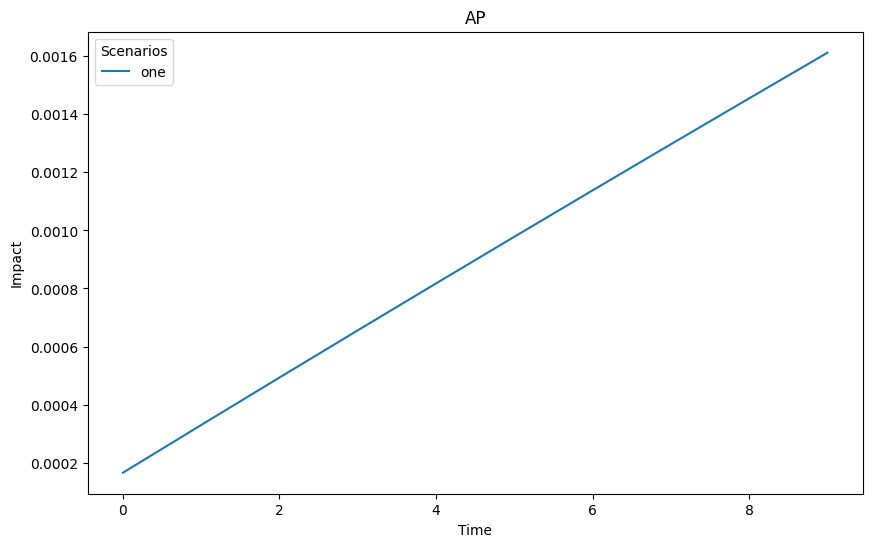

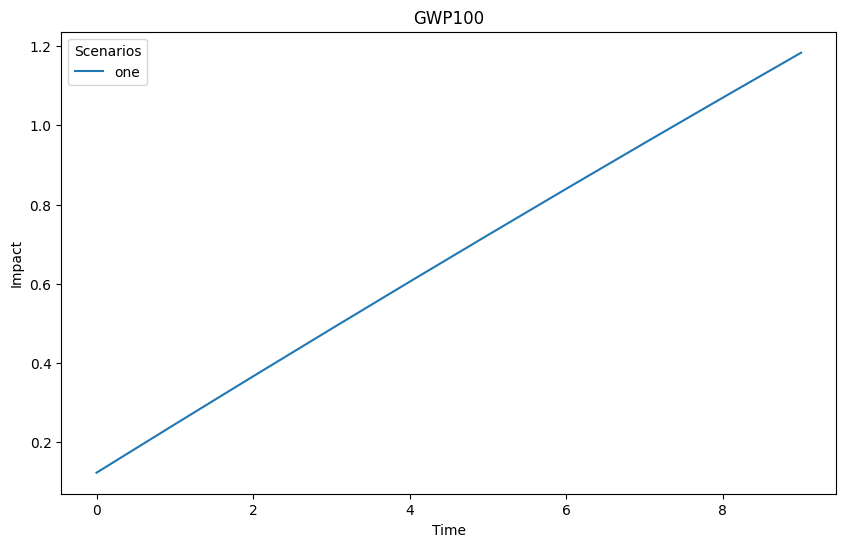

In [78]:
# We can start now with the visualization of the calculated results. First we can use the visualize_dict_lineplots function to make plot how each
# impact categories evolves in time.
# Below we visualize the cumulative impact (dataframes_cum_impact) calculated with the semi-dynamic LCA
dict_cum_impact_per_category = visualize_dict_lineplots(dataframes_cum_impact, impact_categories_names, target_dir, keys_to_plot = ['AP', 'GWP100'], scenarios_to_plot = [scen_names[0]])

We can also do it for the impact calculated with the fully-dynamic LCA.
We can see that the impact calculated is slightly lower because of FCFs calculating the impact up to year 100 regardless of emission timing (see also https://doi.org/10.1016/j.apenergy.2022.120176 for a detailed explanation of this result.)

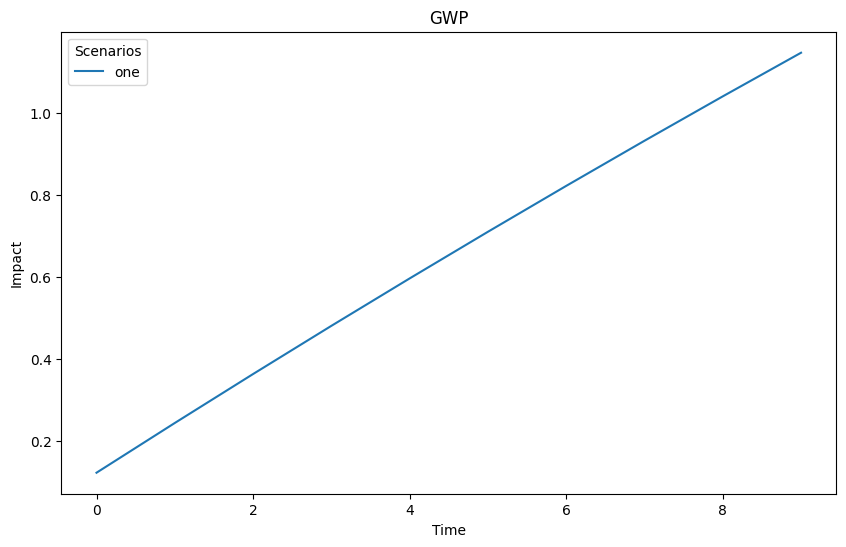

In [79]:
dict_total_impact_per_category_fcf_gwp_graphite = visualize_dict_lineplots(dataframes_cum_impact_fcf_gwp, ['GWP'], target_dir, keys_to_plot = ['GWP'], scenarios_to_plot = ['one'], name = 'FCF_gwp_main_process')

We can use the visualize_dict_lineplots function to make plots of any of the dataframes we created above (e.g., impact per functional unit, cumulative, non-cumulative) we can alos choose which impact categories to visualize (keys_to_plot argument) and we can also visualize multiple scenarios (via the scenarios_to_plot argument (see documentation for more arguments.

Below we plot the impact per functional unit

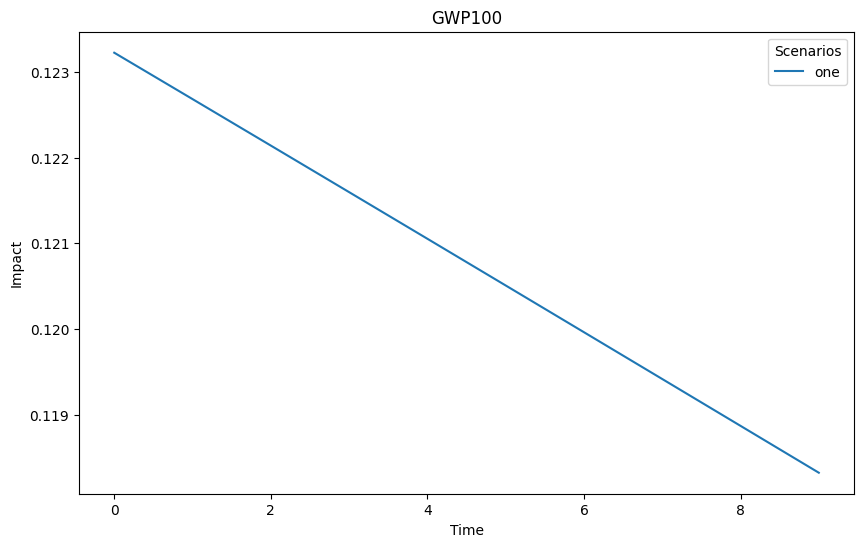

In [80]:
# For semi-dynamic LCA
dict_cum_impact_per_fu_per_category = visualize_dict_lineplots(dataframes_cum_impact_per_fu, impact_categories_names, target_dir, keys_to_plot = ['GWP100'], scenarios_to_plot = ['one'])

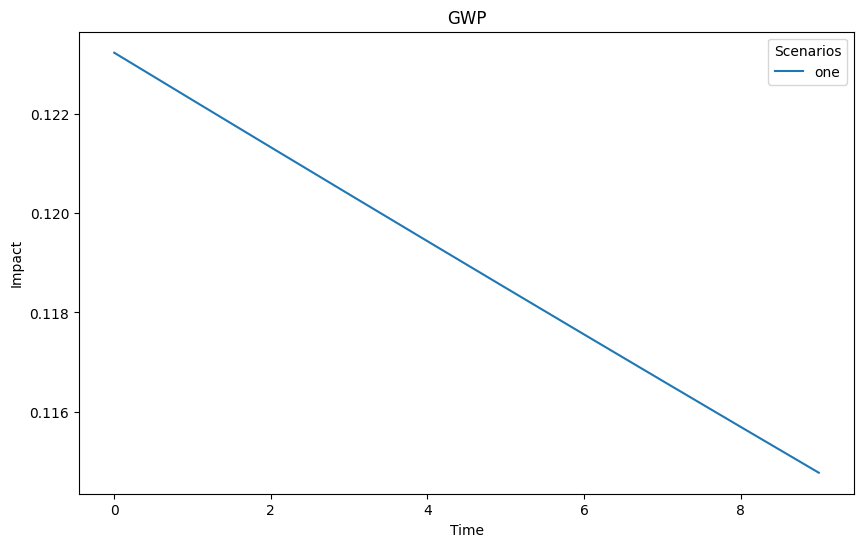

In [81]:
# For fully-dynamic LCA
# See in the below graph that for year 0 the impact is same with the semi dynamic LCA (above figure) but then is less (this is the expected result. We can see that the impac value is the same for year 0 by looking at the dataframes plotted.
dict_cum_impact_per_fu_per_category_fcf_gwp = visualize_dict_lineplots(dataframes_cum_impact_per_fu_fcf_gwp, ['GWP'], target_dir, keys_to_plot = ['GWP'], scenarios_to_plot = ['one'], name = 'FCF_gwp_main_process')

We can also for example calculate the total impact caused each year

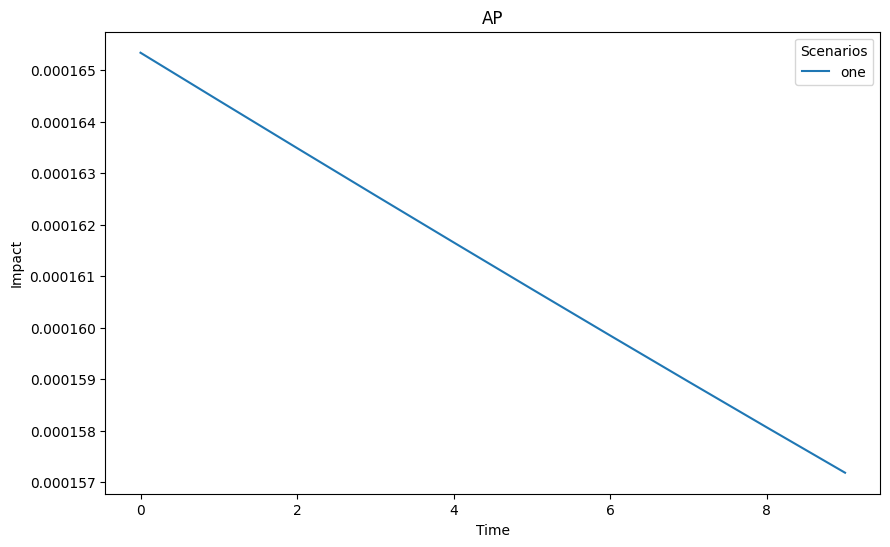

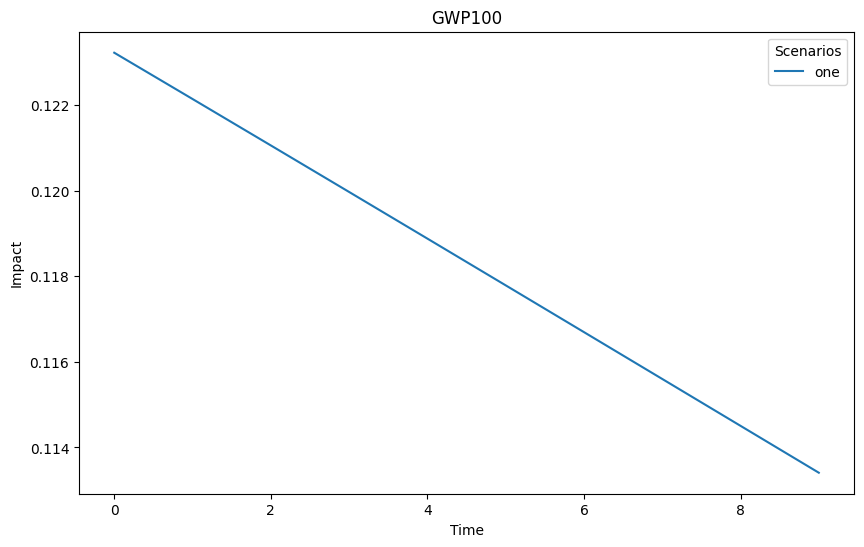

In [82]:
# With semi-dynamic LCA
dict_impact_per_category = visualize_dict_lineplots(dataframes_total_impact, impact_categories_names, target_dir, keys_to_plot = ['AP', 'GWP100'], scenarios_to_plot = ['one'])

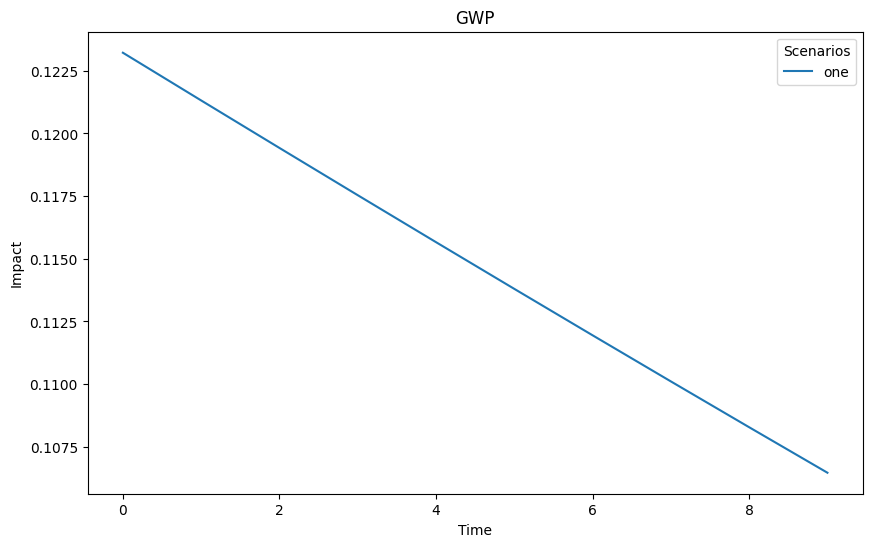

In [84]:
# And with fully-dynamic LCA
dict_total_impact_per_category_fcf_gwp_graphite = visualize_dict_lineplots(dataframes_total_impact_fcf_gwp, ['GWP'], target_dir, keys_to_plot = ['GWP'], scenarios_to_plot = ['one'], name = 'FCF_gwp_main_process')

We can also visualize barcharts and contibution analysis in time:

For the semi-dynamic LCA:

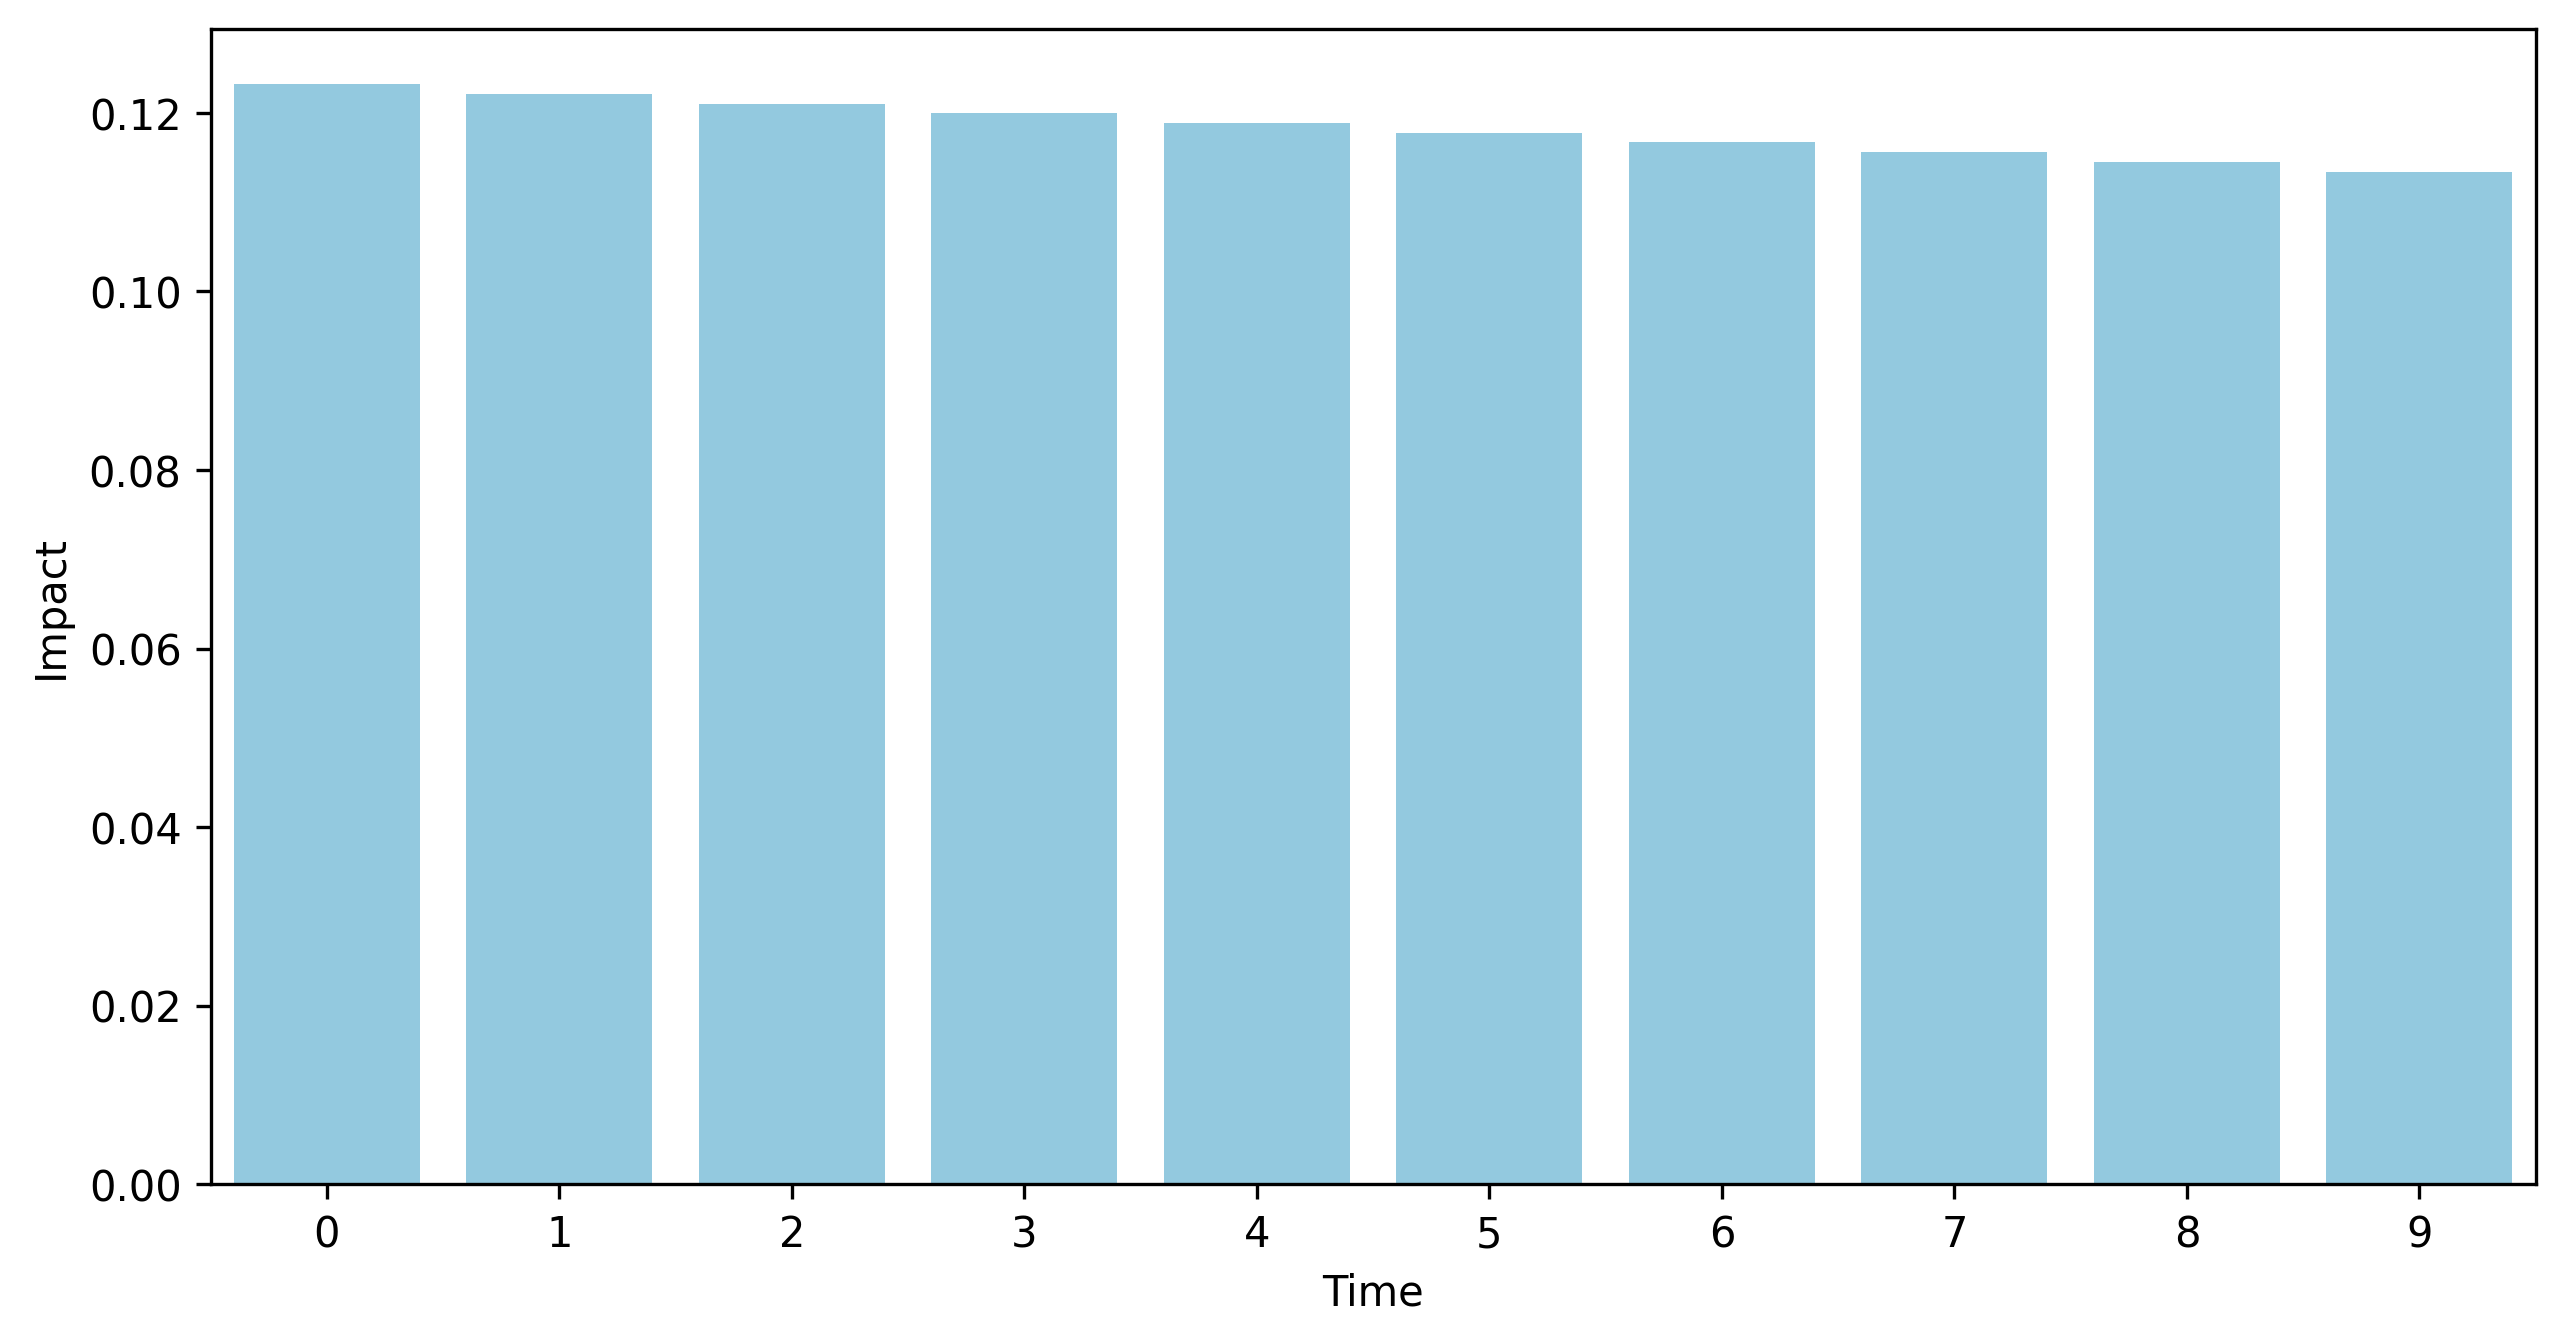

Plot saved: C:\Users\sgkousis\Desktop\Results_for_end_to_end\one_barplot_GWP100__.png


In [85]:
plot_bar_charts_by_category(scenario_dict_total_impact, scenarios_to_plot= ['one'],impacts_to_plot = ['GWP100'], target_dir = target_dir)

And for the fully-dynamic LCA


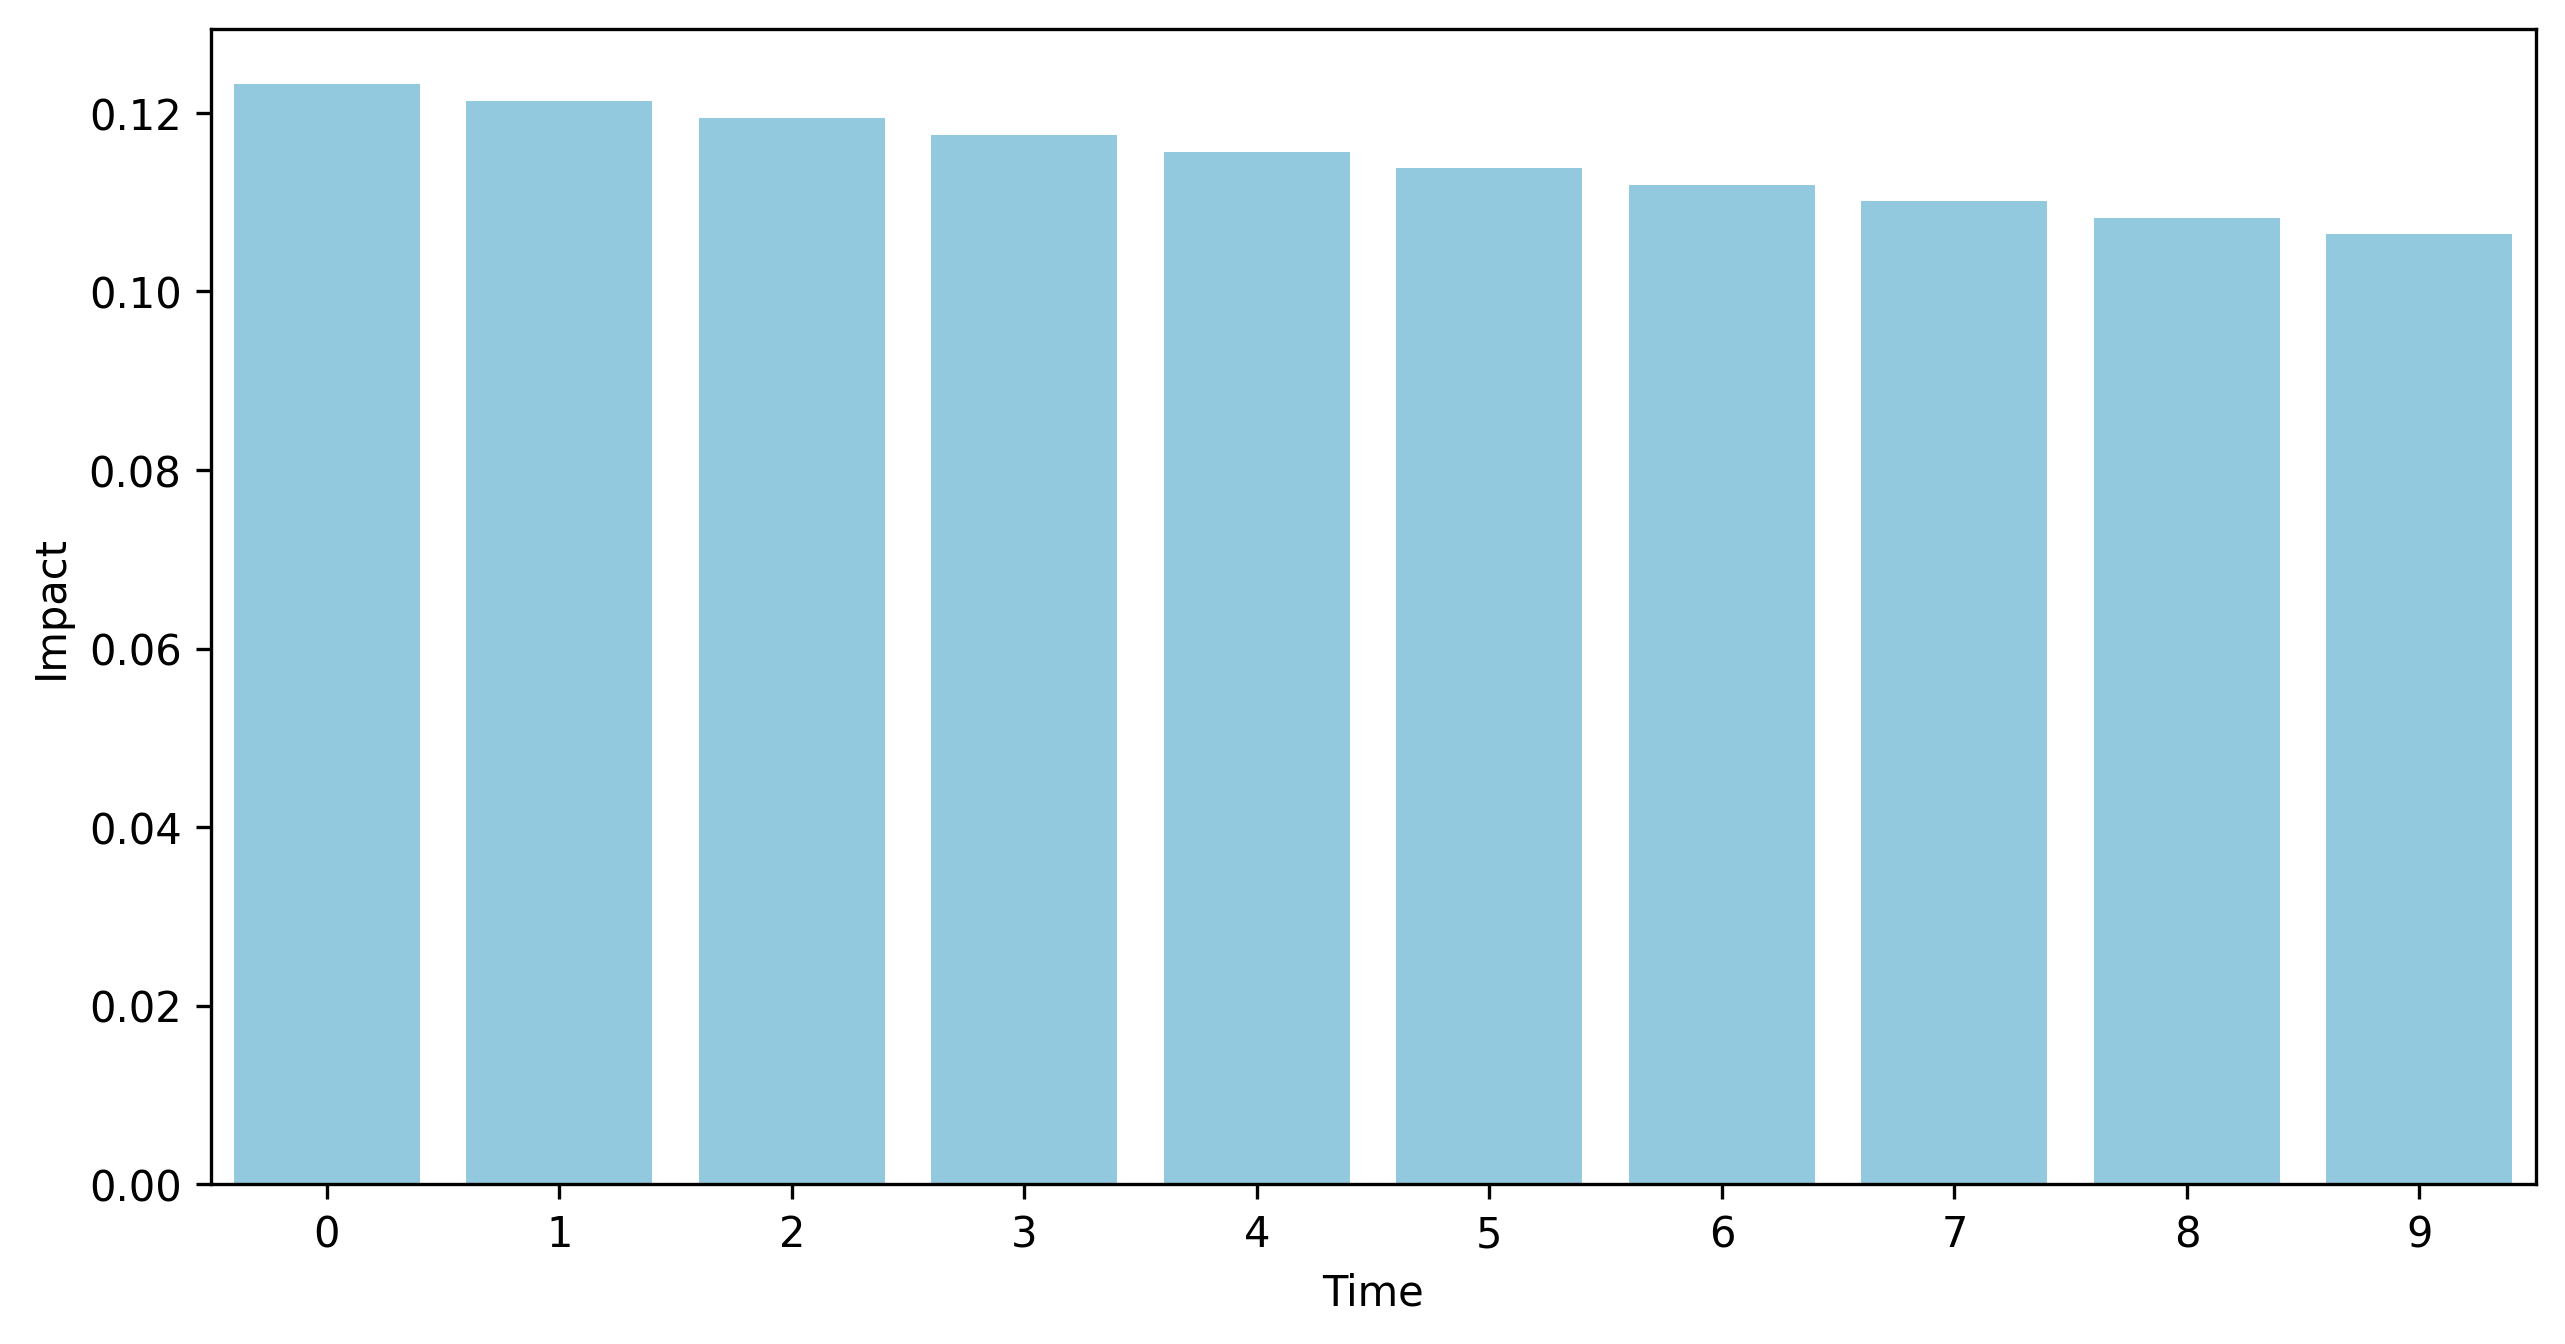

Plot saved: C:\Users\sgkousis\Desktop\Results_for_end_to_end\one_barplot_GWP100_fcf_gwp_main_process_.png


In [87]:
plot_bar_charts_by_category(dict_total_impact_fcf, scenarios_to_plot= ['one'],impacts_to_plot = ['GWP100'], target_dir = target_dir, name = 'fcf_gwp_main_process')

And we can also visualize contribution analysis in time

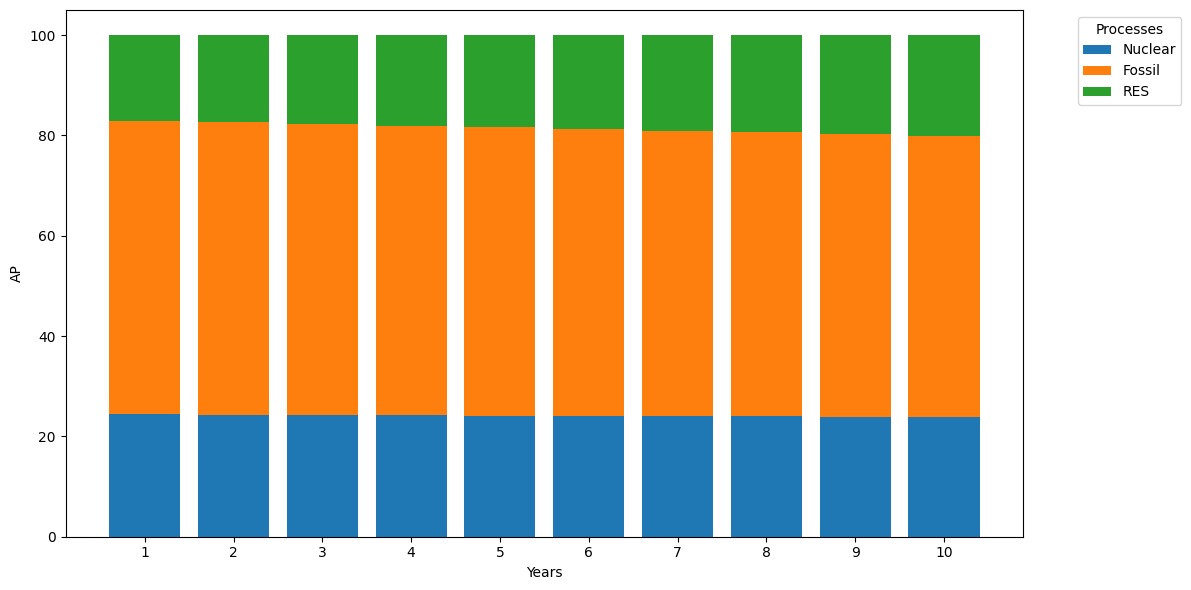

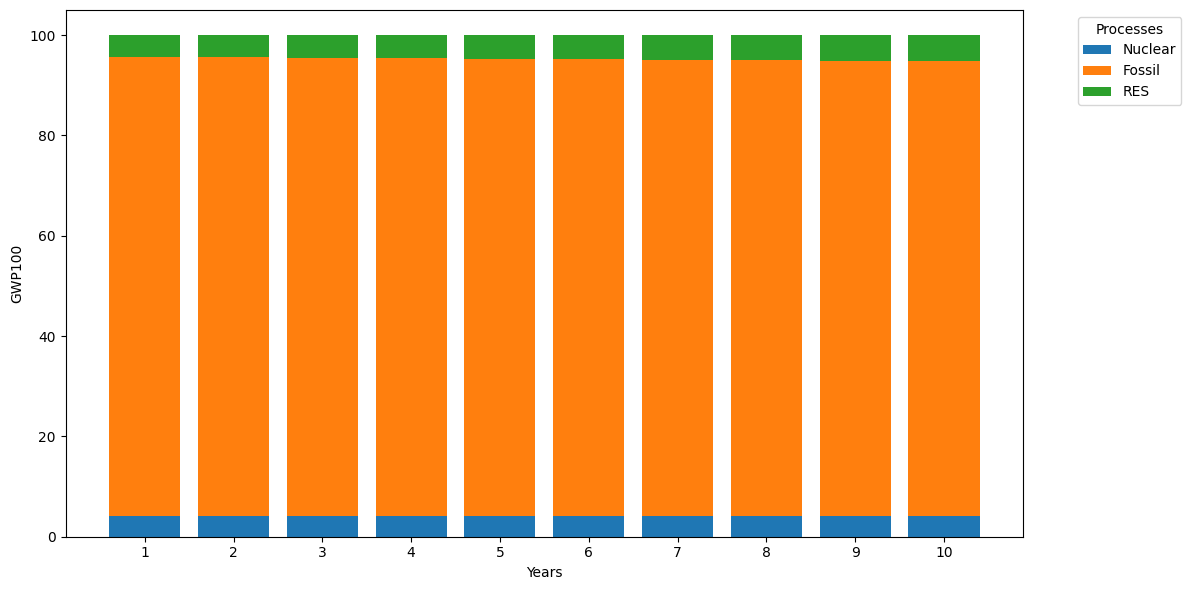

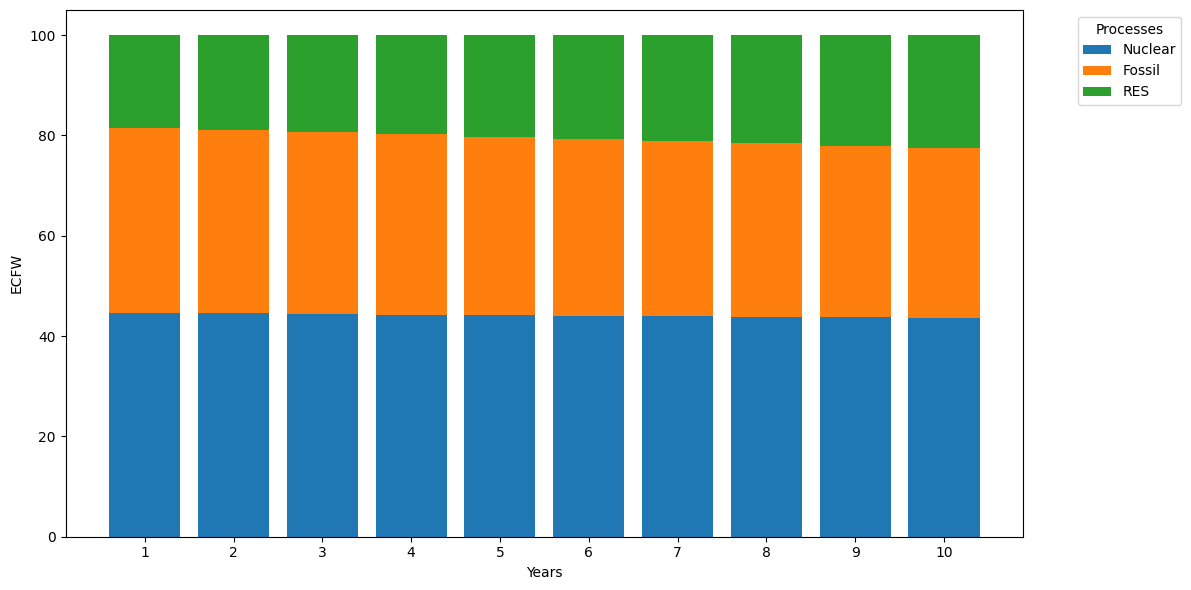

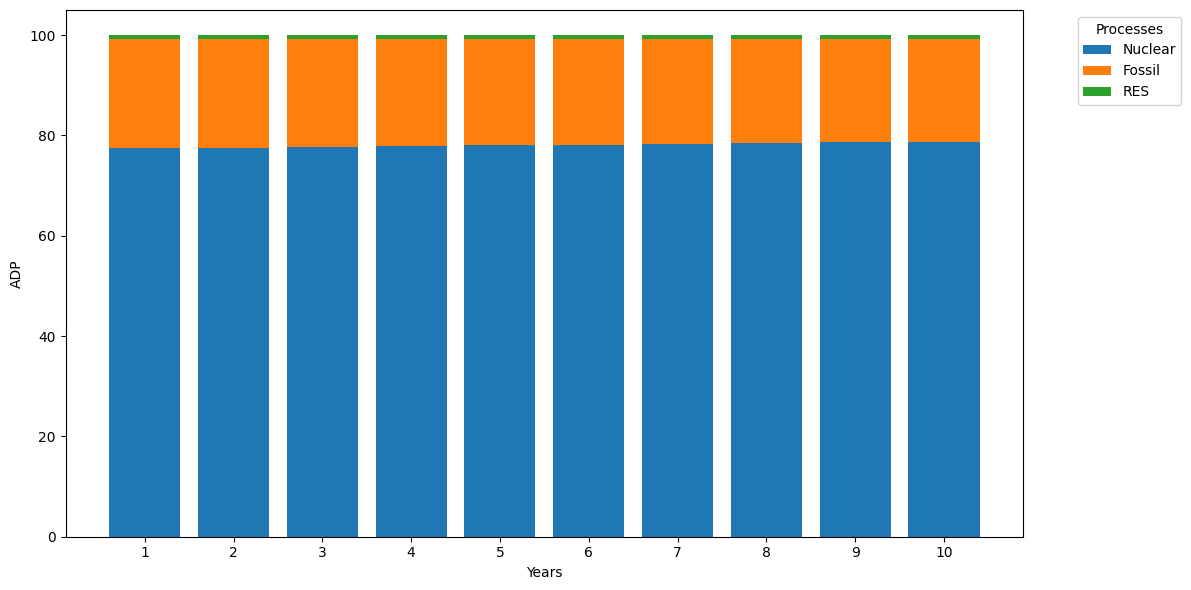

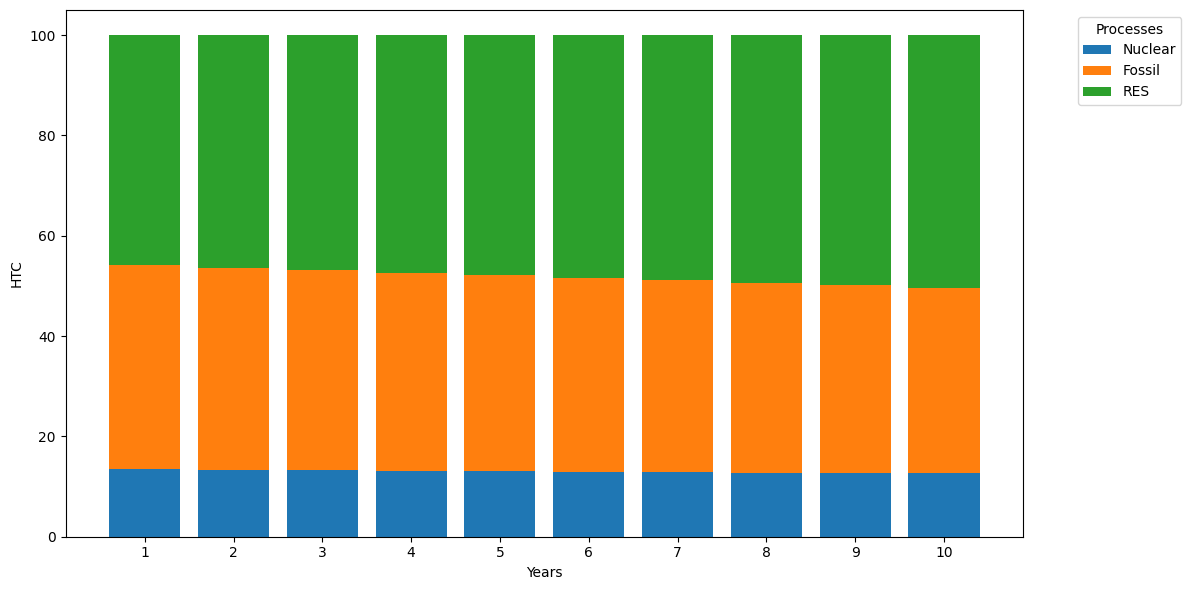

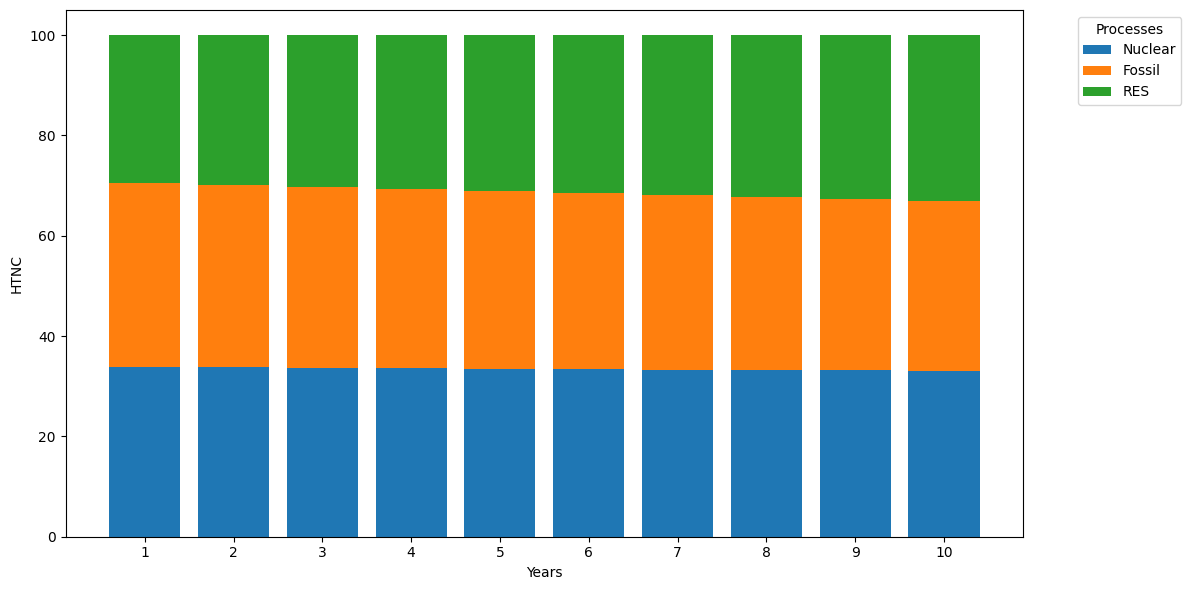

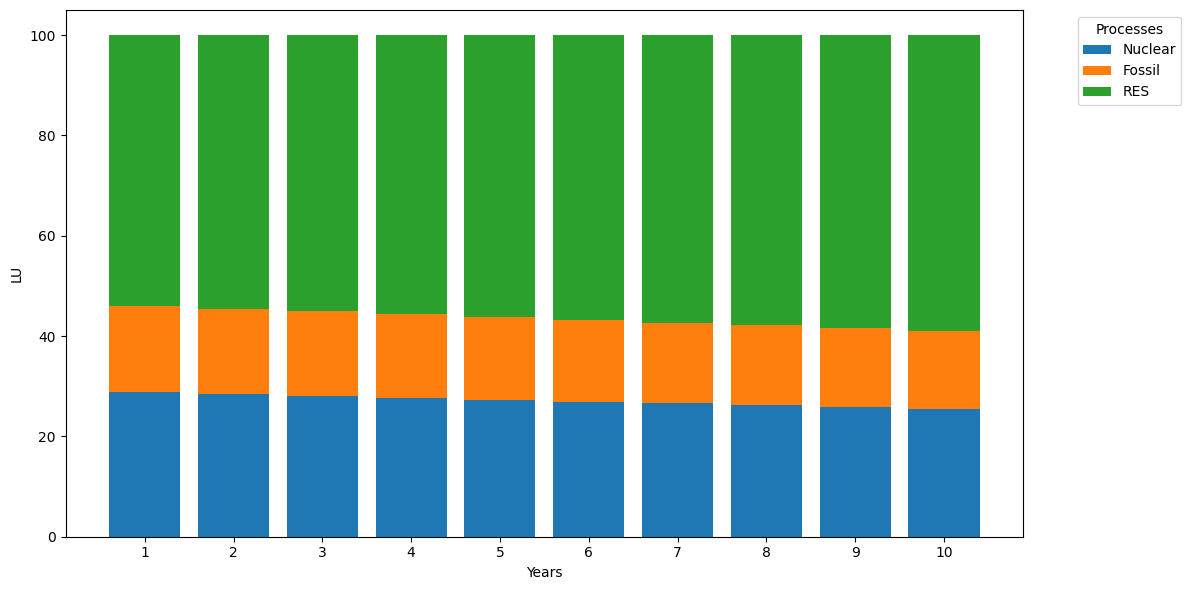

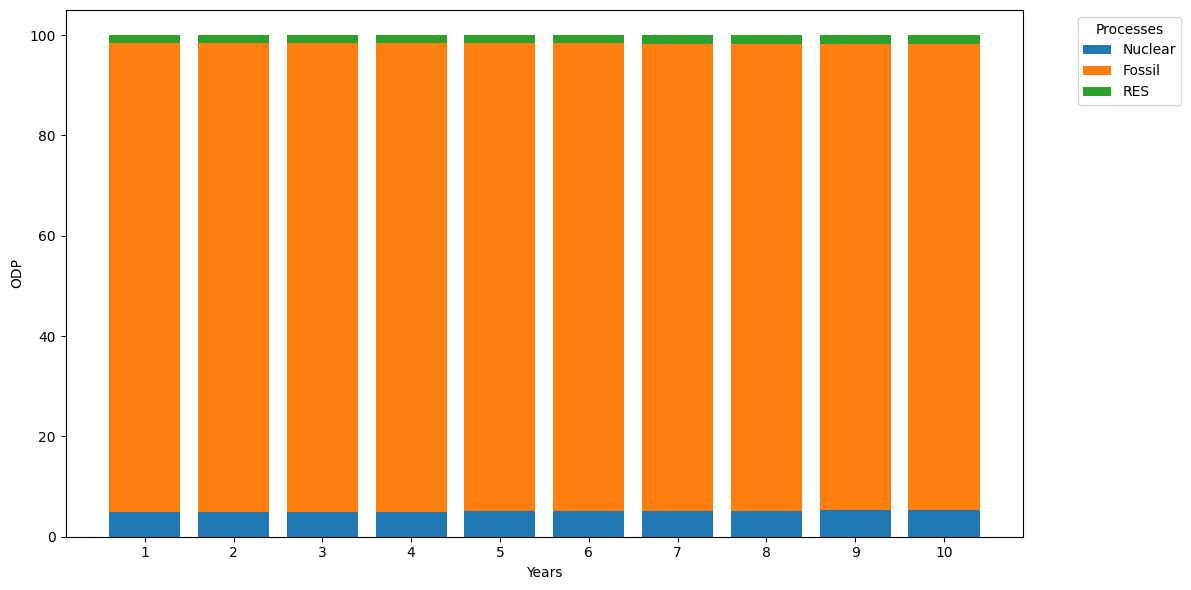

In [89]:
visualize_stacked_barchart_time_series_impact(my_calculator.total_impact_contributions['Electricity production'], 0,  impact_categories_names, mapping_names, target_dir, name = "main process")

We can also visualize and calculate the impact that is caused by the different biosphere flows (e.g., substances emitted). We first need to create a dictionary that matches the biosphere flows (e.g., substances emitted) with the impact they cause each year of the time horizon. We can do this with a dedicated function **map_fcf_icf_results_to_flows**.

Below we create these dictionaries for the results calculated with the semi-dynamic (my_dict_flow), fully-dynamic-FCF (my_dict_fcf_flow), and fully-dynamic-ICF (my_dict_icf_flow)

In [90]:
my_dict_flow = map_fcf_icf_results_to_flows(my_lca.biosphere_dict['Electricity production'], scen_names, my_calculator.total_char_inventory['Electricity production'].sum(axis = 0))

In [91]:
my_dict_fcf_flow = map_fcf_icf_results_to_flows(my_lca.biosphere_dict['Electricity production'], scen_names, my_calculator.total_impact_fcf_per_flow['GWP'])

In [92]:
my_dict_icf_flow = map_fcf_icf_results_to_flows(my_lca.biosphere_dict['Electricity production'], scen_names, my_calculator.total_impact_icf_per_flow['GWP'])

We can then visualize the impact caused each year of the system's lifetime with the plot_fcf_line_per_flow function by giving it the my_dict_fcf_flow or my_dict_flow and specific names for the environmental flow to be plotted (see below for CO2).

In [4]:
plot_fcf_line_per_flow(my_dict_fcf_flow, ['one'], "'Carbon dioxide, fossil' (kilogram, None, ('air', 'urban air close to ground'))", target_dir)

In [5]:
plot_fcf_line_per_flow(my_dict_flow, ['one'], "'Carbon dioxide, fossil' (kilogram, None, ('air', 'urban air close to ground'))", target_dir)

In [6]:
plot_icf_line_per_flow(my_dict_icf_flow, ['one'], "'Carbon dioxide, fossil' (kilogram, None, ('air', 'urban air close to ground'))", target_dir, years_to_plot= 100)

And we can also plot the evolution of the total impact caused calculate with ICFs as:

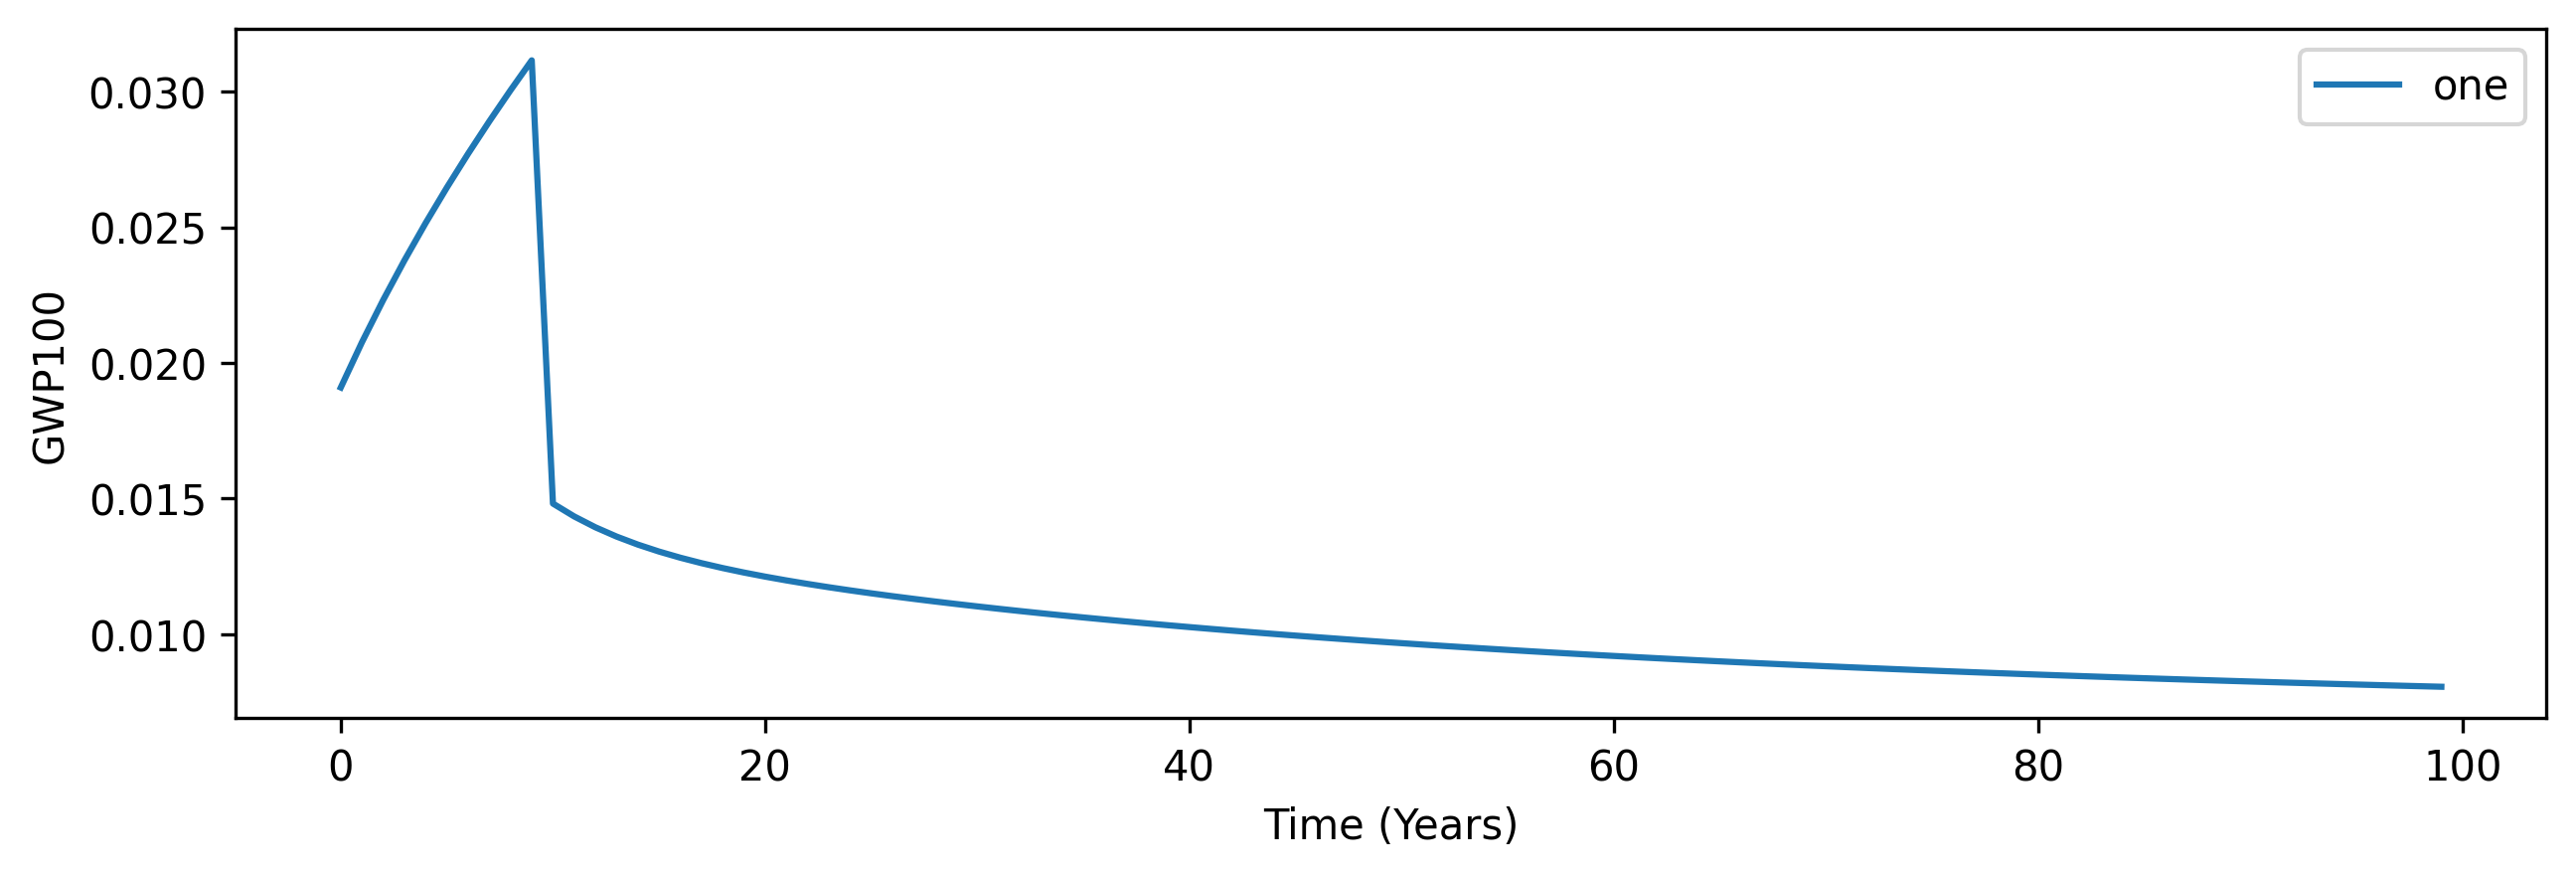

In [96]:
scenario_dict_total_impact_icf = create_scenario_dataframes(my_calculator.total_impact_icf['GWP'], ['GWP100'], scen_names)
plot_icf_line(scenario_dict_total_impact_icf, ['one'], target_dir, years_to_plot=100, category_name='GWP', figsize = (10,3), dpi=300)

We can also add the impact of different biosphere flows as below (we can then plot this)

In [97]:
flow_to_plot = "sum"
flow_list = ["'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))"]
scen_list = ['one']
x_icf = sum_scenarios_per_flow(my_dict_icf_flow, flow_list, scen_list, flow_to_plot)
x_fcf = sum_scenarios_per_flow(my_dict_fcf_flow, flow_list, scen_list, flow_to_plot)
x_semi = sum_scenarios_per_flow(my_dict_flow, flow_list, scen_list, flow_to_plot)

## Note:
More visualizations can be achieved since all results are held in dictonaries, lists and np.arrays.

# Costing and techno-economic analysis

When we defined the system (start of this notebook), we only edfined the system for LCA. For a dynamic LCC/TEA we neeed to define the system with almost the same structure but:

- We need to define discount rate
- We need to define the plant construction and its cost
- We need to define separate lists and revenues for each sub-process

We do these things below. We are going to include the revenues (sale of produced electricity) uniformly to each of the sub-processes (nuclear, fossil, res). One could introduce another sub-process if that would be simpler for the user.

#### Additional parameters for the costing /tea analysis

#### Note:
For the costing and techno-economic analysis, we need to consider the construction of the plant, if we don't want to have a cost for it we can set the cost to zero as we will do for this tutorial. See LCC and TEA example for an analysis that includes the construction. If we want to not take into account the construction and consider only to the first operation year, we need to append the discount_factors array with a 1 at its beginning. We are not going to do this because we want to dicsount to the year before the start of operation.

In [98]:
scen_names = ['one']
headers = ['Cost breakdown']
scenarios = 1
timeframe = 10
time_step = 1
construction_years = 1 # We need to consider the construction of the plant, if we don't want to have a cost for it we can set the cost to zero as we will do for this tutorial. See LCC and TEA example for an analysis that included the construction
number_of_infrastructure_processes = 1 # We need to consider the construction of the plant
discount_rate = 0.05

In [99]:
discount_factors = np.exp(-discount_rate*np.arange(timeframe//time_step))
# We also define tow dummy arrays for convenience
dummy_parameter = np.full((scenarios, timeframe//time_step),1.)
dummy_parameter_construction = np.full((scenarios, construction_years),1.)

Because we changed the number of constrcuton years we need to re-run the system parametric modelling (one could simply re-run the previous cells) but lets copy paset them here (Note, if we had an infrastructure process in LCA we would not need to do this).

In [100]:
bwr_growth = (1. + 0.02)
pwr_growth = (1. - 0.01)
hydro_growth = (1. + 0.01)
dge_growth = (1. + 0.04)
wind_growth = (1. + 0.02)
#Define the growth rates of the cost and prices
bwr_growth_cost = (1. + 0.02)
pwr_growth_cost = (1. - 0.01)
hydro_growth_cost = (1. + 0.01)
dge_growth_cost = (1. + 0.01)
wind_growth_cost = (1. + 0.02)
elec_growth_price = (1. + 0.01)
# Define the installed capacities
NG_ccpp_capacity = np.full((scenarios, timeframe // time_step), 400.)
NG_convpp_capacity = np.full((scenarios, timeframe // time_step), 750.)
BWR_capacity = np.zeros((scenarios, timeframe // time_step))
PWR_capacity = np.zeros((scenarios, timeframe // time_step))
Hydro_pumped_capacity = np.zeros((scenarios, timeframe // time_step))
DGE_capacity = np.zeros((scenarios, timeframe // time_step))
Wind_1_3_capacity = np.zeros((scenarios, timeframe // time_step))
for i in range(scenarios):
    for j in range(timeframe // time_step):
        BWR_capacity[i, j] = 1500 * (bwr_growth ** j)
        PWR_capacity[i, j] = 800 * (pwr_growth ** j)
        Hydro_pumped_capacity[i, j] = 800 * (hydro_growth ** j)
        DGE_capacity[i, j] = 85 * (dge_growth ** j)
        Wind_1_3_capacity[i, j] = 980 * (wind_growth ** j)
#  Define the total system capacity
total_capacity = BWR_capacity + PWR_capacity + NG_ccpp_capacity + NG_convpp_capacity + Hydro_pumped_capacity + DGE_capacity + Wind_1_3_capacity
# Calculate the shares:
bwr_share = BWR_capacity / total_capacity
pwr_share = PWR_capacity / total_capacity
ng_ccpp_share = NG_ccpp_capacity / total_capacity
ng_convpp_share = NG_convpp_capacity / total_capacity
hydro_share = Hydro_pumped_capacity / total_capacity
dge_share = DGE_capacity / total_capacity
wind_share = Wind_1_3_capacity / total_capacity
# We define the amount we consider to be produced annually (this is important for more complex analysis (e.g., a plant producing multiple tonnes)/
total_fu = np.full((scenarios, timeframe // time_step), 1.)
# We need to put this into a list.

# We consider that the plant operates 8000 hours/year, with this being constant for the 10 years of operation.
cap_fac = np.full((scenarios, timeframe // time_step), 8000.)
# We calculate the discount factors for each year

# We calculate the related costs/prices and their evolution in time
NG_ccpp_cost = np.full((scenarios, timeframe // time_step), 0.09)
NG_convpp_cost = np.full((scenarios, timeframe // time_step), 0.095)
BWR_cost = np.zeros((scenarios, timeframe // time_step))
PWR_cost = np.zeros((scenarios, timeframe // time_step))
Hydro_pumped_cost = np.zeros((scenarios, timeframe // time_step))
DGE_cost = np.zeros((scenarios, timeframe // time_step))
Wind_1_3_cost = np.zeros((scenarios, timeframe // time_step))
Elec_selling_price = np.zeros((scenarios, timeframe // time_step))
for i in range(scenarios):
    for j in range(timeframe // time_step):
        BWR_cost[i, j] = 0.1 * (bwr_growth_cost ** j)
        PWR_cost[i, j] = 0.12 * (pwr_growth_cost ** j)
        Hydro_pumped_cost[i, j] = 0.12 * (hydro_growth_cost ** j)
        DGE_cost[i, j] = 0.13 * (dge_growth_cost ** j)
        Wind_1_3_cost[i, j] = 0.09 * (wind_growth_cost ** j)
        Elec_selling_price[i, j] = 0.11 * (elec_growth_price ** j)

# We also define tow dummy arrays for convenience
dummy_parameter = np.full((scenarios, timeframe // time_step), 1.)
dummy_parameter_construciton = np.full((scenarios, construction_years), 1.)

In [101]:
keys_plant_construction_cost = {
    "Plant construction": ""
}

construction_amounts_costs = [
    0.*dummy_parameter_construction
]

keys_plant_construction_revenues = {
    '': '',
}

construction_amounts_revenues = [
    0*dummy_parameter_construction
]

keys_nuclear_cost = {
    'BWR': "",
    'PWR': ""
}

nuclear_amounts_cost = [BWR_cost,
                   PWR_cost]

keys_nuclear_revenues = {
    'Produced electricity': "",
}

nuclear_amounts_revenues = [Elec_selling_price/3.]

keys_fossil_cost = {
    'NG-CCPP': "",
    'NG-Conventional': ""
}

fossil_amounts_cost = [NG_ccpp_cost,
                   NG_convpp_cost,]

keys_fossil_revenues = {
    '': "",
}

fossil_amounts_revenues  = [Elec_selling_price/3.]

keys_res_cost = {
    'Hydro': "",
    'DGE': "",
    'Wind': ""
}

res_amounts_cost = [Hydro_pumped_cost,
                DGE_cost,
               Wind_1_3_cost]

keys_res_revenues = {
    '': "",
}

res_amounts_revenues  = [Elec_selling_price/3.]

keys_main_process = {
    "Construction": "",
    "Nuclear": "",
    "Fossil": "",
    "RES": ""
}

exchanges_amounts_main_process = [
1.*dummy_parameter,
1.*dummy_parameter,
1.*dummy_parameter,
1.*dummy_parameter,
]

Similarly to what we did for the LCA we first structure the information. We do this both for the cost- and revenue- describing dictionaries and lists

In [102]:
list_with_keys_costs = [keys_plant_construction_cost, keys_nuclear_cost, keys_fossil_cost,
                        keys_res_cost]

list_with_keys_revenues = [keys_plant_construction_revenues, keys_nuclear_revenues,
                           keys_fossil_revenues, keys_res_revenues]

exchanges_revenues_list = [construction_amounts_revenues, nuclear_amounts_revenues,
                           fossil_amounts_revenues, res_amounts_revenues]

exchanges_list = [construction_amounts_costs, nuclear_amounts_cost,
                  fossil_amounts_cost, res_amounts_cost]

In [103]:
mapping_names_costs = create_mapping(keys_main_process, list_with_keys_costs, number_of_infrastructure_processes, tea_op=True)
mapping_names_construction_costs = create_mapping(keys_main_process, list_with_keys_costs, number_of_infrastructure_processes, tea_con=True)
mapping_names_total_costs = create_mapping(keys_main_process, list_with_keys_costs)

In [104]:
mapping_names_revenues = create_mapping(keys_main_process, list_with_keys_revenues, number_of_infrastructure_processes, tea_op=True)
mapping_names_construction_revenues = create_mapping(keys_main_process, list_with_keys_revenues, number_of_infrastructure_processes, tea_con=True)
mapping_names_total_revenues = create_mapping(keys_main_process, list_with_keys_revenues)

In [105]:
mapping_exchanges_costs = create_mapping(keys_main_process, exchanges_list, number_of_infrastructure_processes, tea_op=True)
mapping_exchanges_construction_costs = create_mapping(keys_main_process, exchanges_list, number_of_infrastructure_processes, tea_con=True)
mapping_exchanges_total_costs = create_mapping(keys_main_process, exchanges_list)

In [106]:
mapping_exchanges_revenues = create_mapping(keys_main_process, exchanges_revenues_list, number_of_infrastructure_processes, tea_op=True)
mapping_exchanges_construction_revenues = create_mapping(keys_main_process, exchanges_revenues_list, number_of_infrastructure_processes, tea_con=True)
mapping_exchanges_total_revenues = create_mapping(keys_main_process, exchanges_revenues_list)

In [107]:
unique_activities_cost = create_list_with_unique_activities(list_with_keys_costs)
unique_activities_rev = create_list_with_unique_activities(list_with_keys_revenues)

In [108]:
mapping_main_process = {
    'Main process': list(keys_main_process.keys())
    }
mapping_exch_main_process = create_mapping(mapping_main_process, [exchanges_amounts_main_process])

Next we define the cotsing and techno-economic calculator

In [109]:
my_calculator = FastTeaCalculator(number_of_infrastructure_processes, construction_years, scenarios, discount_rate)

### Calculations

And now we can start the calculations

We first calculate the cost of each sub-process and per sub-sub-process discounted at the first operational year. We do the same for the revenues.

In [110]:
my_calculator.cost_calculation(mapping_exchanges_costs, discount_factors)
my_calculator.cost_calculation(mapping_exchanges_construction_costs, discount_factors, infrastructure=True)
my_calculator.revenue_calculation(mapping_exchanges_revenues, discount_factors)

We now can save and visualize the undiscounted costs and revenues with the calculate_undiscounted_cost_contributions_per_process function:

In [111]:
my_calculator.cost_calculation(mapping_exchanges_costs, discount_factors)
my_calculator.cost_calculation(mapping_exchanges_construction_costs, discount_factors, infrastructure=True)
my_calculator.revenue_calculation(mapping_exchanges_revenues, discount_factors)

We now can save and visualize the undiscounted costs and revenues with the calculate_undiscounted_cost_contributions_per_process function:

In [112]:
# For the costs:
calculate_undiscounted_cost_contributions_per_process(mapping_names_costs, mapping_names_construction_costs, mapping_exchanges_costs, mapping_exchanges_construction_costs, headers, mapping_main_process, target_dir)

Excel file saved as C:\Users\sgkousis\Desktop\Results_for_end_to_end\scen_0_year_0__cost_breakdown.xlsx
Excel file saved as C:\Users\sgkousis\Desktop\Results_for_end_to_end\scen_0_year_0__cost_total.xlsx


In [113]:
# And for the revenues:
calculate_undiscounted_cost_contributions_per_process(mapping_names_revenues, mapping_names_construction_revenues, mapping_exchanges_revenues,
                                                      mapping_exchanges_construction_revenues, headers,
                                                      mapping_main_process, target_dir, file_name_total= 'Revenues_total.xlsx',
                                                      file_name_contributions='Revenues_contributions.xlsx', rev = 'revenues');

C:\Users\sgkousis\Desktop\end_to_end_\.venv\lib\site-packages\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
C:\Users\sgkousis\Desktop\end_to_end_\.venv\lib\site-packages\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
C:\Users\sgkousis\Desktop\end_to_end_\.venv\lib\site-packages\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
C:\Users\sgkousis\Desktop\end_to_end_\.venv\lib\site-packages\lcpy\hvs

Excel file saved as C:\Users\sgkousis\Desktop\Results_for_end_to_end\scen_0_year_0_revenues_Revenues_total.xlsx


C:\Users\sgkousis\Desktop\end_to_end_\.venv\lib\site-packages\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
C:\Users\sgkousis\Desktop\end_to_end_\.venv\lib\site-packages\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))


Excel file saved as C:\Users\sgkousis\Desktop\Results_for_end_to_end\scen_0_year_0_revenues_Revenues_contributions.xlsx


We now can calculate the in-time evolution of the costs and revenues, cumulativey and non-cumulatively , for the main process and per sub-process.

We do this with the total_cost_calculation, total_revenue_calculation, and total_cost_calculation_including_infrastructure (for that case) functions.

In [114]:
my_calculator.total_cost_calculation(discount_factors, 'Electricity production')
my_calculator.total_revenue_calculation(discount_factors, 'Electricity production')

In [115]:
my_calculator.total_cost_calculation_including_infrastructure(discount_factors, 'Electricity production')

Before we move on we need to restrictucture the dictionary holding the revenues this can be fixed with the refine_revenue_dicts function

In [116]:
my_calculator.refine_revenue_dicts(name = 'Electricity production')

Our cost and revenue results for each year and in different forms (cumulative, non-cumulative) are now held in attributes/dictionaries of the my_calculator instance

We can use the create_and_save_dataframes_time_series function to extract, save, and visualize these results. Depending on which attributes we give to the function we cna extact, visualize and store different result types. Some examples follow. The results are stored in excel sheets and are visualized with both the excel sheets and figures being saved at the target_dir wwe set at the begining of theis tutorial. To save them we need to set the "save" argument to True.

In [117]:
# For example if we want the non-cumulative cost evolution results
dataframes_total_non_cum_cos = create_and_save_dataframes_time_series(my_calculator.non_cum_cost['Electricity production'], ['Non-cumulative-cost'], scen_names, excel_file_name= os.path.join(target_dir, 'non_cumulative_cost_output.xlsx'), save = True)
# Or the cumulative
dataframes_total_cum_cost = create_and_save_dataframes_time_series(my_calculator.cum_cost['Electricity production'], ['Cumulative-cost'], scen_names, excel_file_name= os.path.join(target_dir, 'cumulative_cost_output.xlsx'), save = True)
# Or the non-cumulative revenues
dataframes_total_cum_rev = create_and_save_dataframes_time_series(my_calculator.cum_revenue['Electricity production'], ['Cumulative Revenues'], scen_names, excel_file_name= os.path.join(target_dir, 'cumulative_revenues_output.xlsx'), save = True)
# Or the cumulative revenues
dataframes_total_non_cum_rev = create_and_save_dataframes_time_series(my_calculator.non_cum_revenue['Electricity production'], ['Revenues'], scen_names, excel_file_name= os.path.join(target_dir, 'non_cumulative_revenues_output.xlsx'), save = True)

The above-created dataframes can be directly visualized with the visualize_dataframes_time_series function

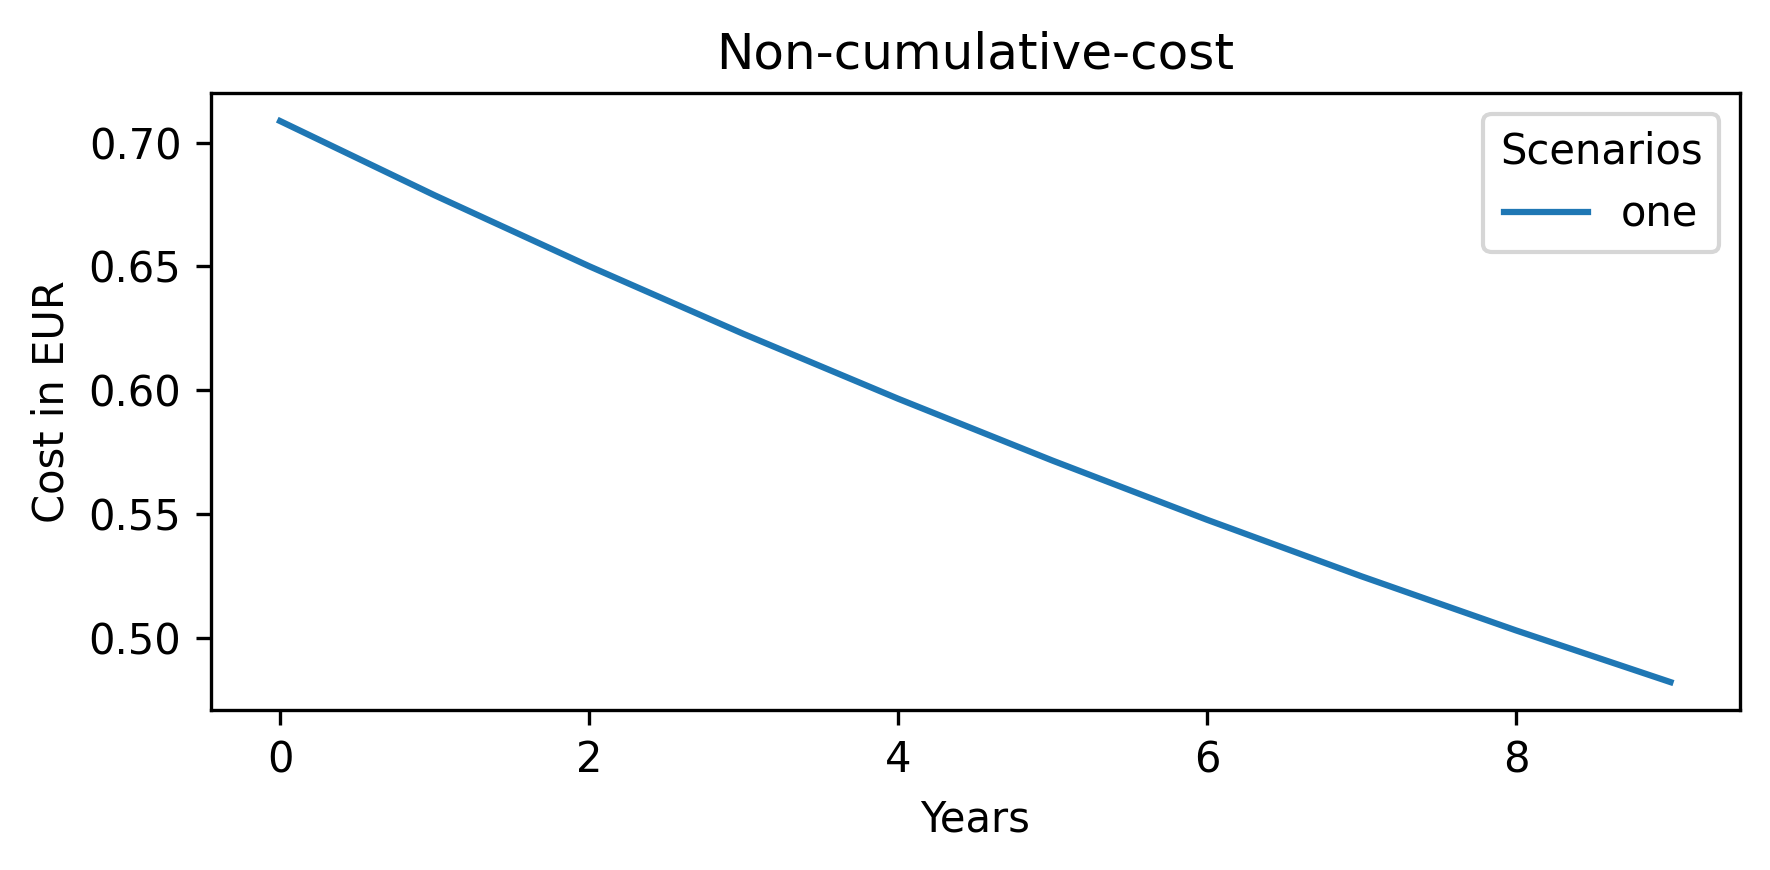

In [118]:
visualize_dataframes_time_series(dataframes_total_non_cum_cos, ['Non-cumulative-cost'], scen_names, 'Years', 'Cost in EUR', 'Non-cumulative-cost', os.path.join(target_dir, 'non_cumulative_cost_output.png'))

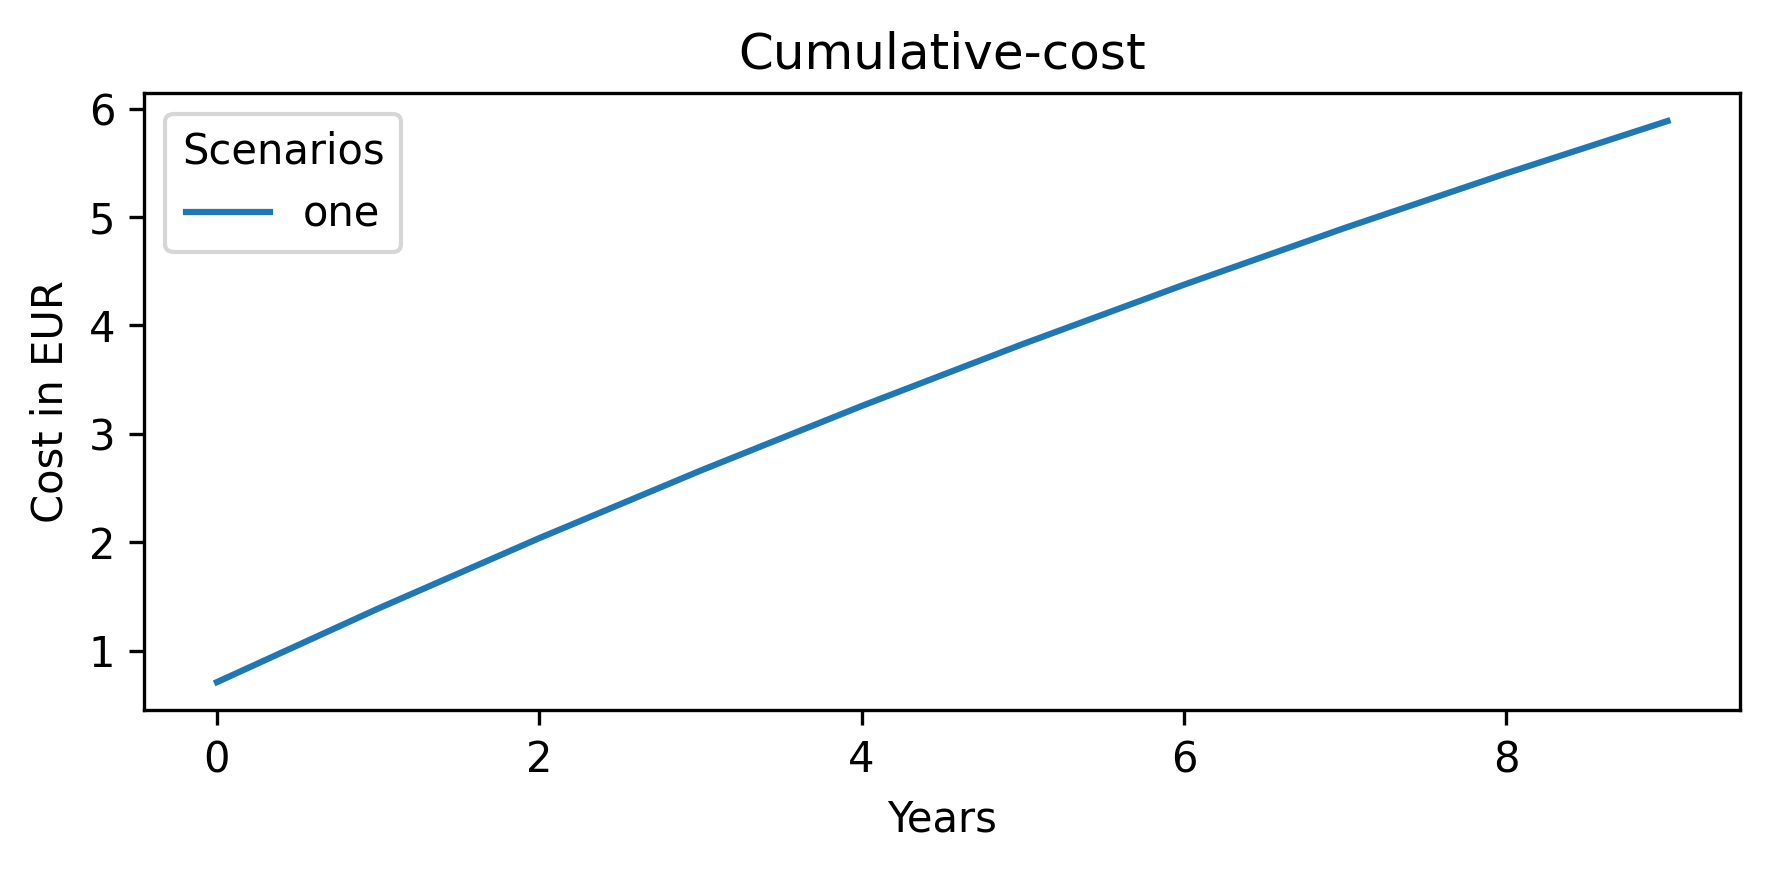

In [119]:
visualize_dataframes_time_series(dataframes_total_cum_cost, ['Cumulative-cost'], scen_names, 'Years', 'Cost in EUR', 'Cumulative-cost', os.path.join(target_dir, 'cumulative_cost_output.png'))

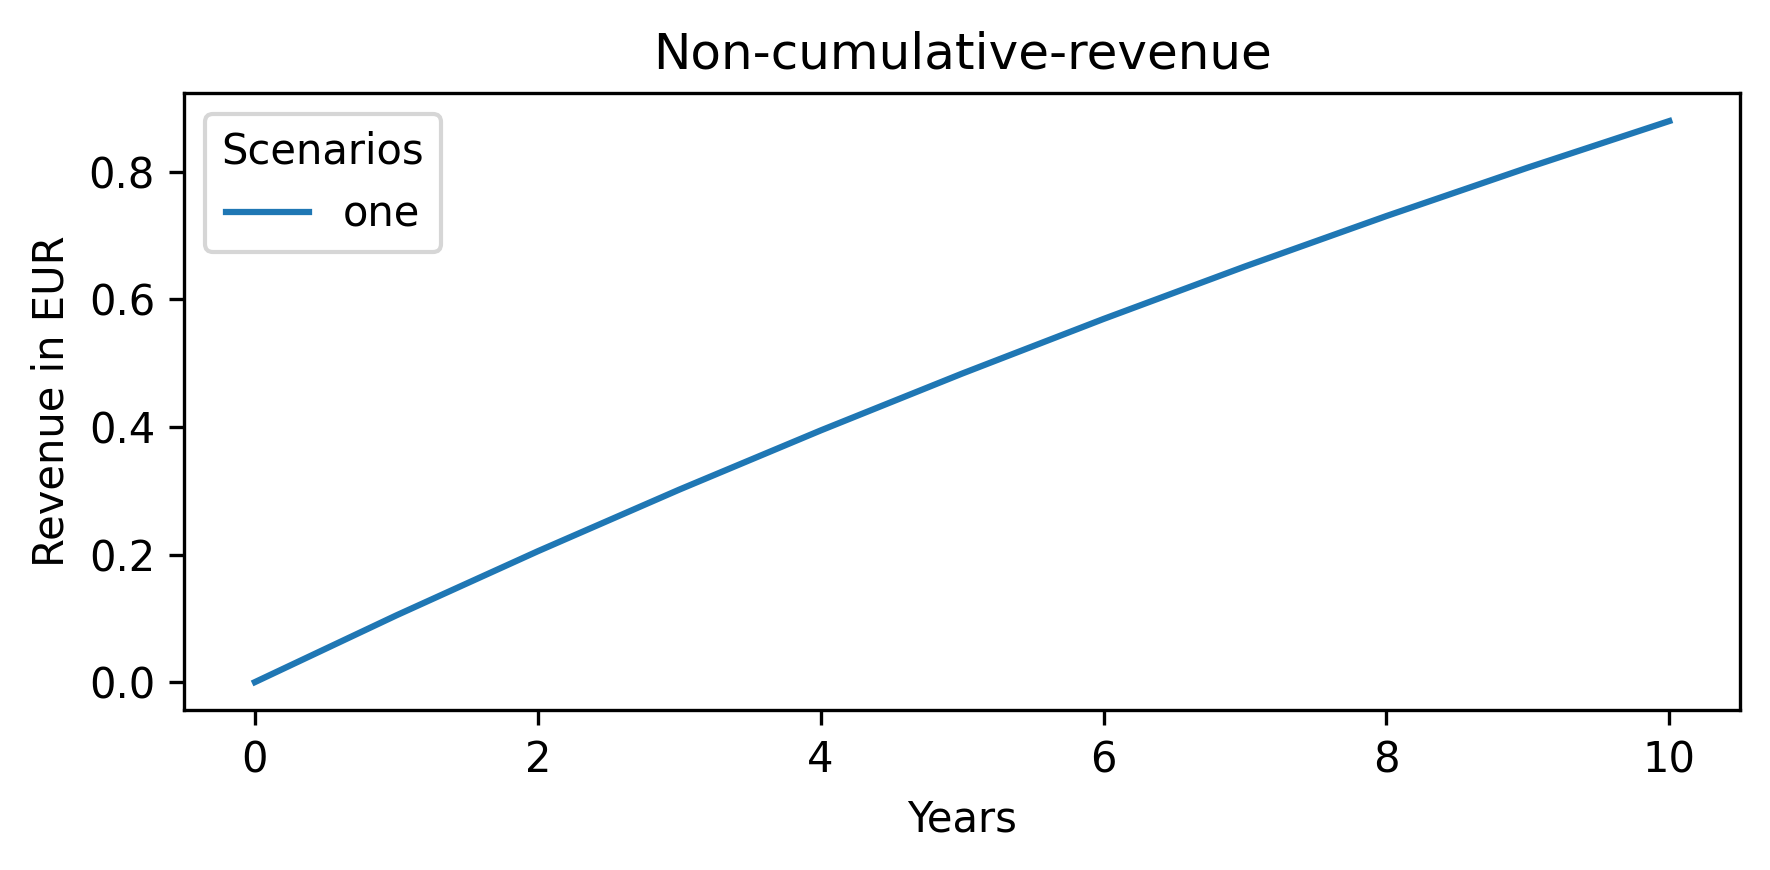

In [120]:
visualize_dataframes_time_series(dataframes_total_cum_rev, ['Cumulative-revenue'], scen_names, 'Years', 'Revenue in EUR', 'Non-cumulative-revenue', os.path.join(target_dir, 'cumulative_revenue_output.png'))

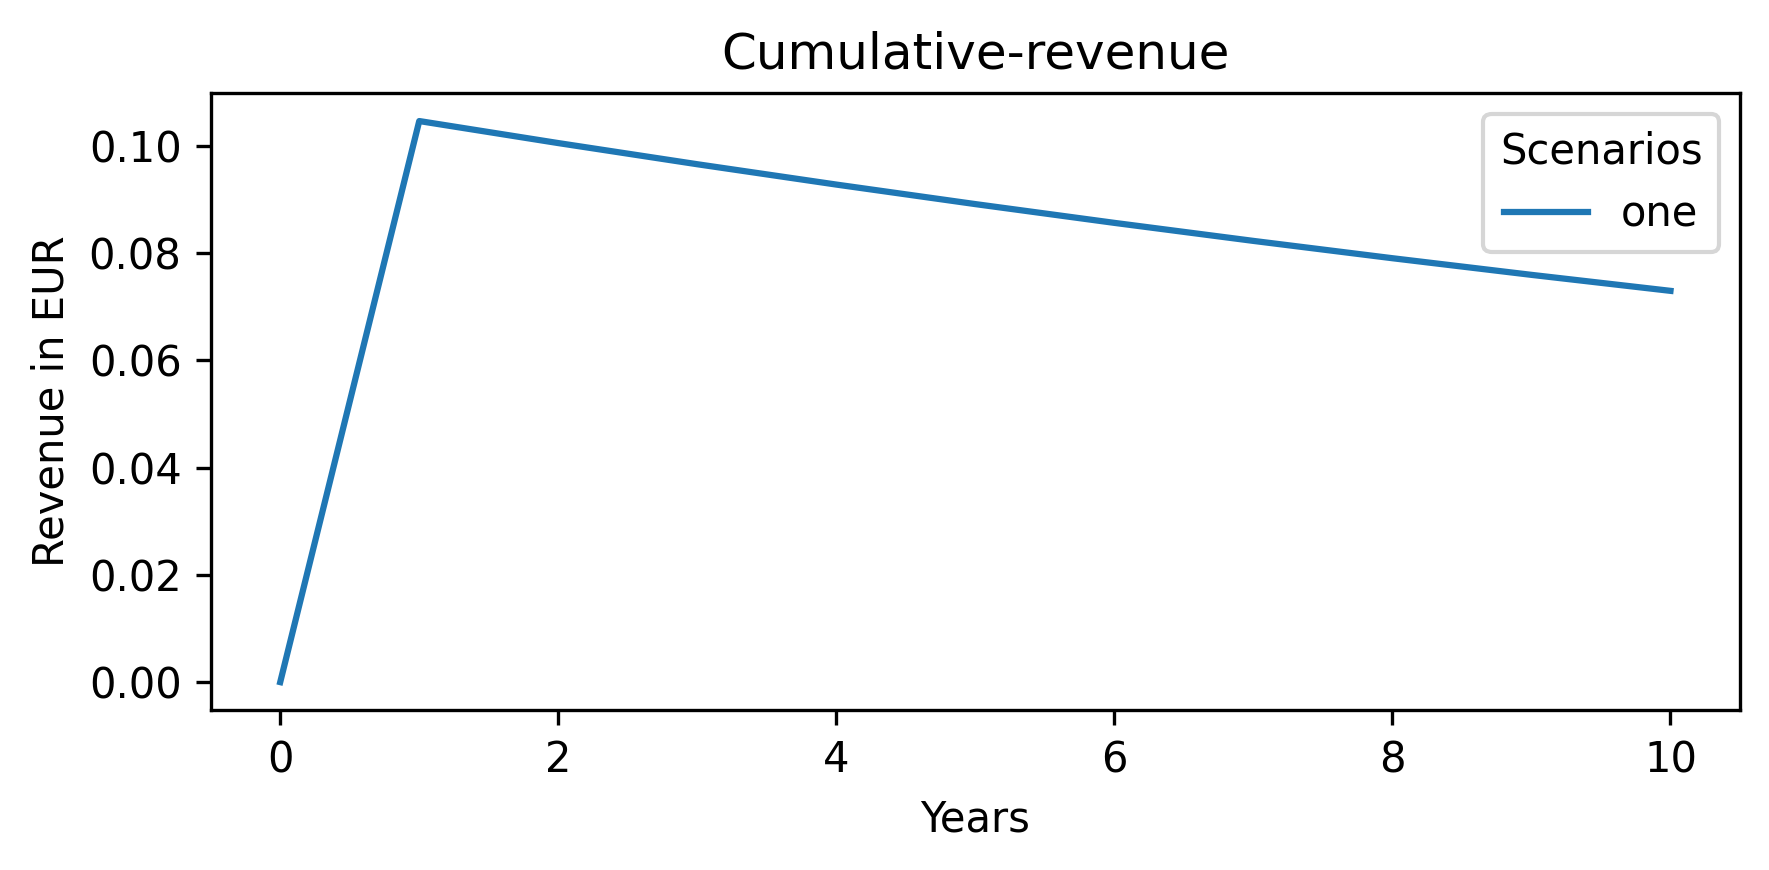

In [121]:
visualize_dataframes_time_series(dataframes_total_non_cum_rev, ['Non-cumulative-revenue'], scen_names, 'Years', 'Revenue in EUR', 'Cumulative-revenue', os.path.join(target_dir, 'non_cumulative_revenue_output.png'))

So up to now we have calculated, stored, and visualized the in-time evolution of the costs and revenues of the system we are investigating.

We can calculate the NPV of the system with the npv_calculation function

In [122]:
my_calculator.npv_calculation(discount_factors, name = 'Electricity production')

If we want to include taxes, depreciations etc. in the NPV calculation we can use the npv_calculation_depreciation function:

In [123]:
tax_rate = 0.2
loan_percentage = 0.3
loan_years = 5
loan_rate = 0.02
depreciation_years = 5

my_calculator.npv_calculation_depreciation(discount_factors, 'Electricity production', tax_rate,
                                           loan_percentage, loan_years, loan_rate, depreciation_years)

And we can also calculate the annualized cost with:

In [124]:
my_calculator.annualized_cost_calculation('Electricity production')

#### Note: see the LCC and TEA example for cost of production calculations.

#### Further visualizations and result handling:

We can visualize the evolution of the NPV in time with the visualize_npv_in_time function.

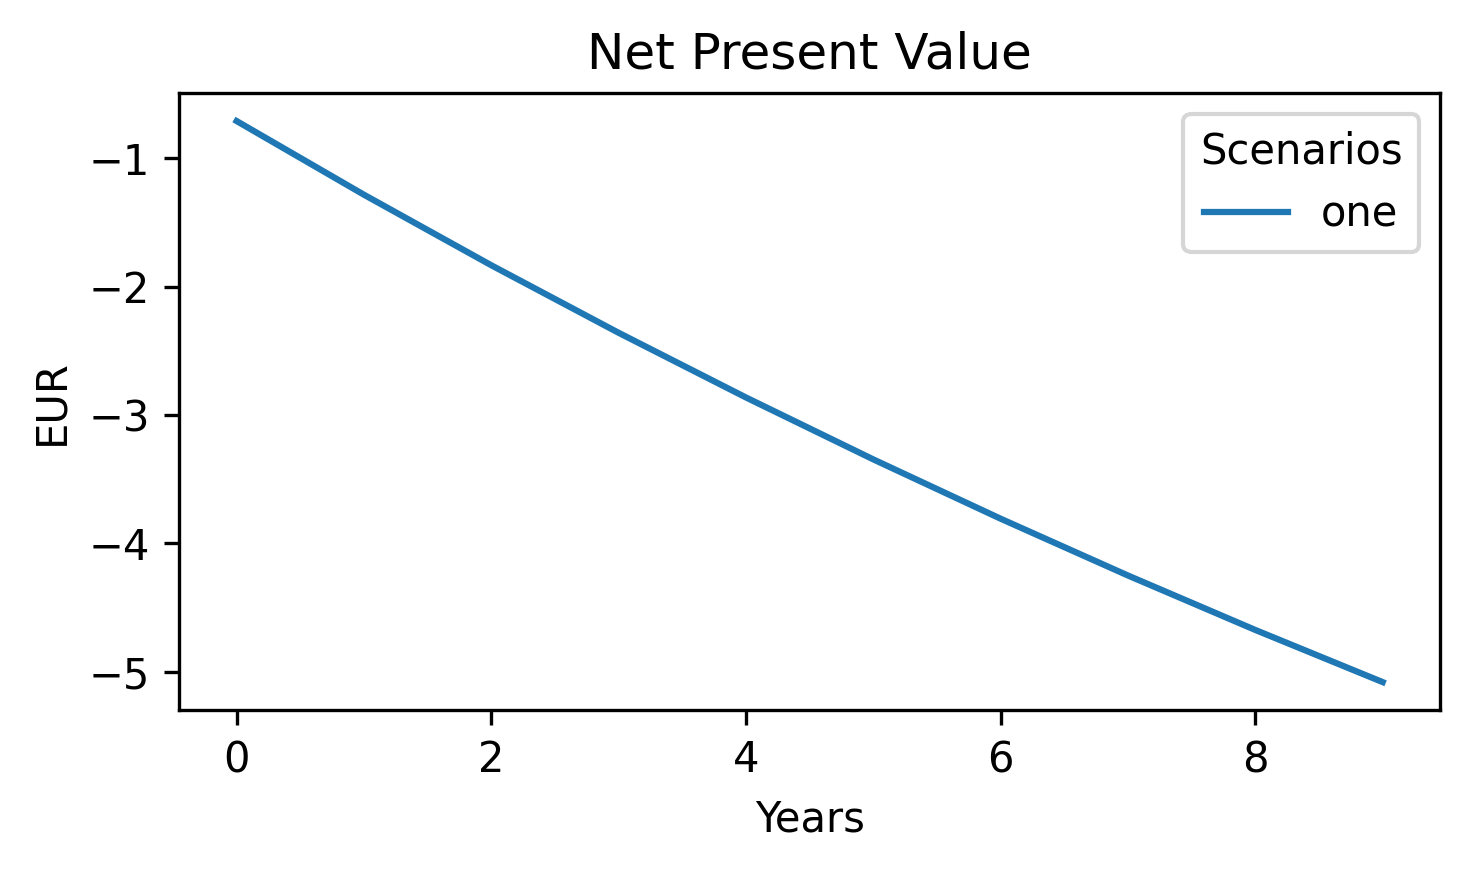

In [125]:
visualize_npv_in_time(dataframes_total_cum_rev, dataframes_total_cum_cost, scen_names, os.path.join(target_dir, 'npv_all_scenarios.png'))

We can plot contribution analysis in-time

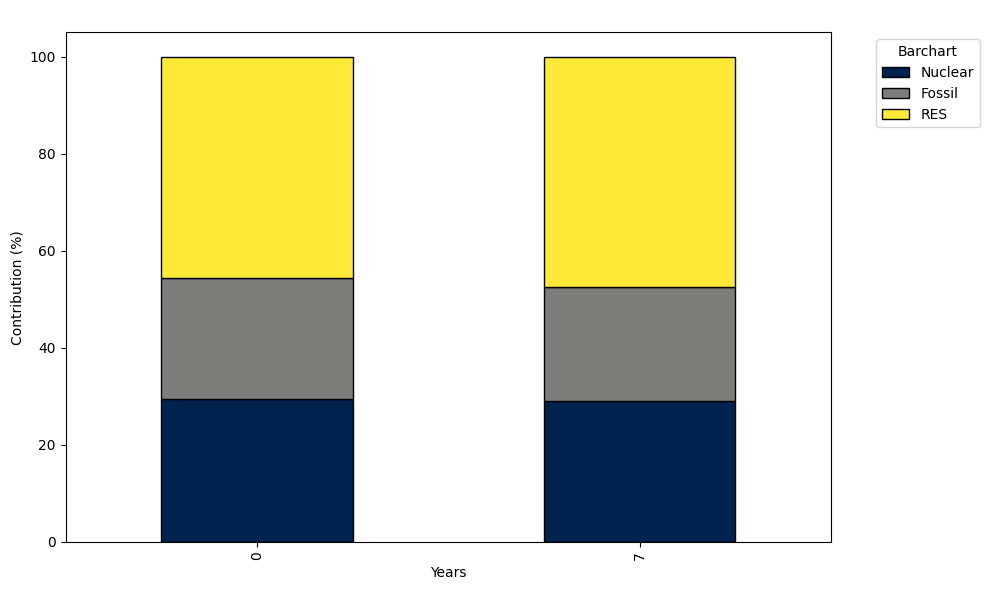

In [126]:
visualize_stacked_barcharts(mapping_names_costs, my_calculator.non_cum_cost_per_process['Electricity production'],
                            scen_names, 7, os.path.join(target_dir, 'stacked_barchart.png'), 'one', 'Contribution (%)', 'Years', ' ')

We can also create a list with the parameters we want to save and visualize, and a list with the respective names we want them saved and visualized as. We can then use the npv_results_storage_and_vis function to store and visualzie these results.

In [127]:
list_for_storage_and_vis_function = [my_calculator.npv['Electricity production'], my_calculator.total_costs['Electricity production'],
                                     my_calculator.operational_costs['Electricity production'],
                                     my_calculator.total_revenue['Electricity production']]
names_for_storage_and_vis_function = ['NPV', 'Total Cost', 'Operational Cost', 'Total Revenue']
names_for_y_axis_of_boxplots = ['million EUR', 'million EUR', 'million EUR', 'million EUR']

npv_results_storage_and_vis(list_for_storage_and_vis_function, names_for_storage_and_vis_function,
                            names_for_y_axis_of_boxplots, target_dir, 'boxplot_results.xlsx')

And finally, we can also make some contirbution analysis for the costs and the revenues of the system:

First we need to create the needed dictionaries holding dataframes with results. We do this with the create_dictionary_with_dfs function, one time for the cost and one time for the revenues.

In [128]:
dict_with_dfs_cost, dict_with_dfs_cost_contr = create_dictionary_with_dfs(mapping_names_costs, my_calculator.cost_per_process, 0, 'Cost')
dict_with_dfs_revenues, dict_with_dfs_revenues_contr = create_dictionary_with_dfs(mapping_names_revenues, my_calculator.revenue_per_process, 0, 'Revenues')

And we then create from these dictionaries some other dictionaries that will be used for the visualization. We create them with the contribution_per_sub_sub_processes function and we plot them with the plot_stacked_percentage_bar_sub_processes function.

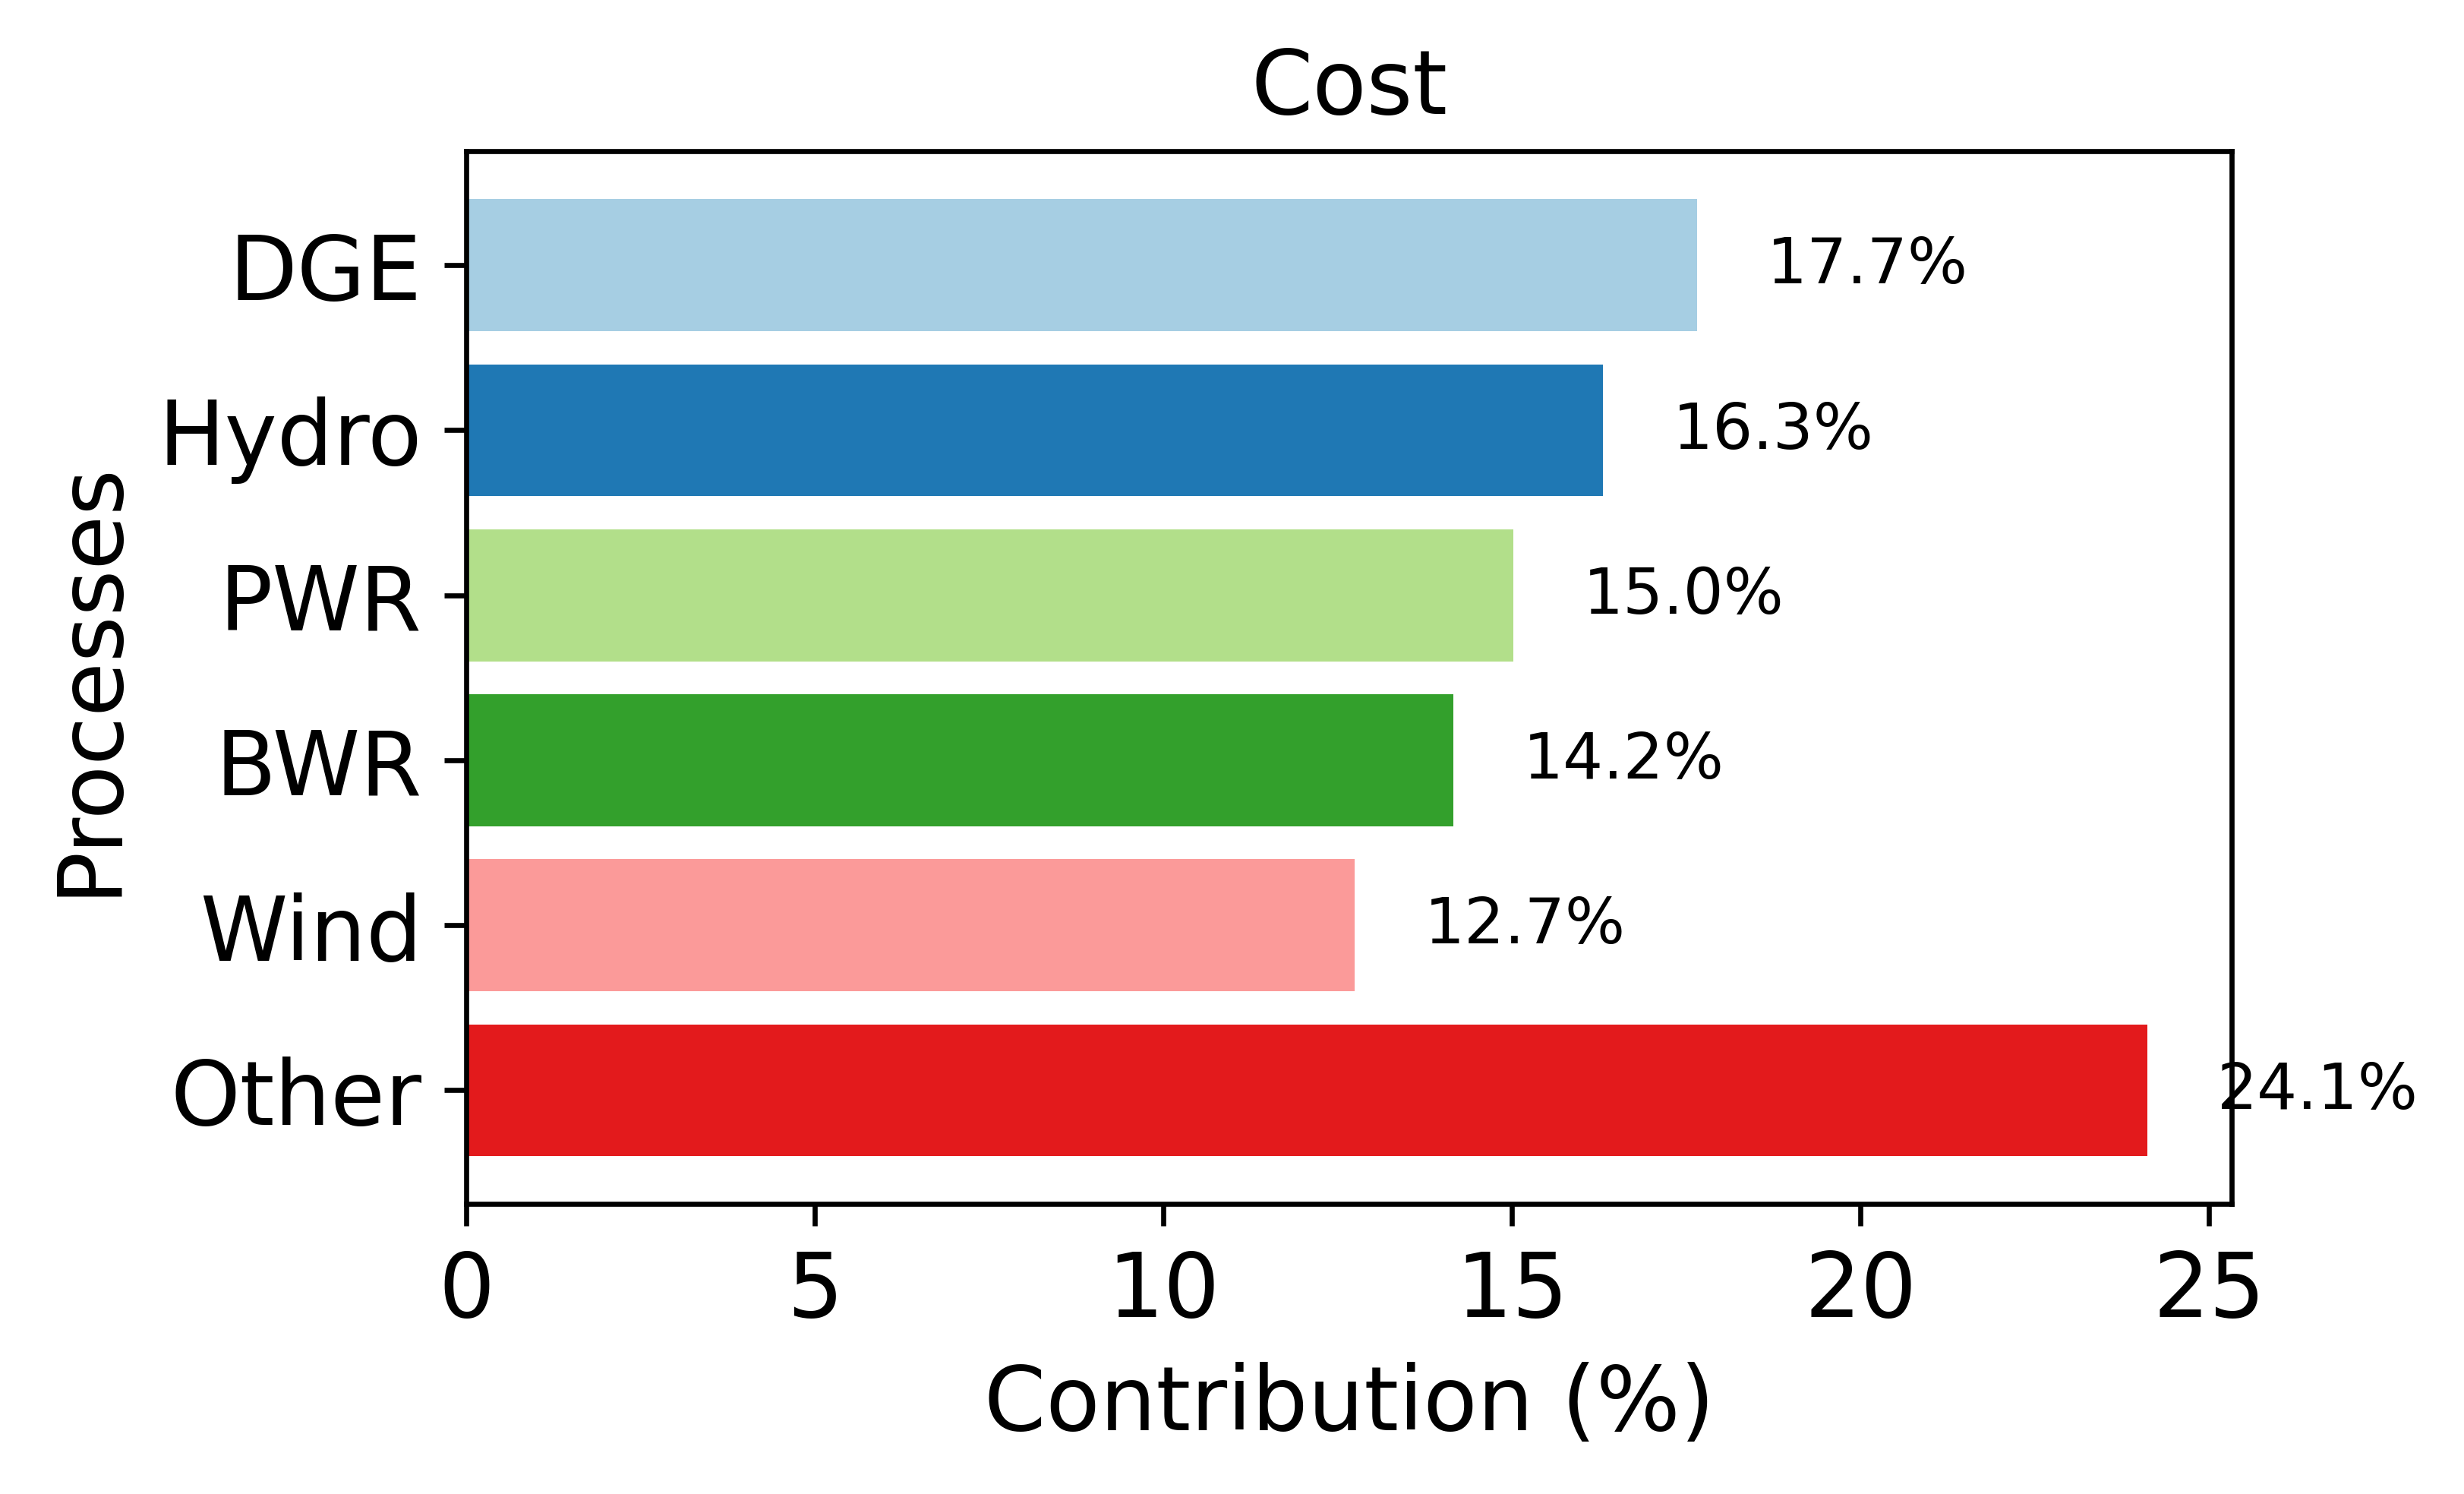

In [129]:
# For the costs:
cost_per_sub_sub_process_dict =  contribution_per_sub_sub_processes(dict_with_dfs_cost, dict_with_dfs_cost_contr, unique_activities_cost, ['Cost'], name= 'electricity_production', save = 'True', target_dir = target_dir)
plot_stacked_percentage_bar_sub_processes(cost_per_sub_sub_process_dict, 'Cost', os.path.join(target_dir, f"sub_process_contributions_cost.png"), verbose = 'False', top_x = 5 )

# Monte Carlo (MC)

All above analysis (both the LCA and the costing) was ran with the scenarios parameter equal to 1. To run an uncertainty analysis (e.g., an MC simulation) we need to set the scenarios parameter to a larger number (e.g., 10000) and assign introduce uncertainty in the modelled system. Then all the above functions can run for the expanded system.

In this section of the tutorial we are going to run an MC analysis for the system modelled and for the LCA and Costing analysis to calcualte boxplots for the system's impacts and NPV. We are going to stop the analysis there. However, we note that all the above function work with the expanded syhstems as well. The only additional thing that needs to be done is to set the scen_names parameter to have the same length as the scenarios (something like scen_names = [str(i) for i in range(scenarios)] and then in the visualization functions for lines dataframes etc, the specific scenarios to be plotted/saved can be picked.

### LCA

Since we increase the number of scenarios and assign uncertainties we need to refine the system modelling to reflect these changes.

In [130]:
scenarios = 10000
timeframe = 10  #operational lifetime after construction
time_step = 1
construction_years = 0
number_of_infrastructure_processes = 0
scen_names = [str(_) for _ in range(scenarios)]

Lest consider the growth rates certain:

In [131]:
bwr_growth = (1. + 0.02)
pwr_growth = (1. - 0.01)
hydro_growth = (1. + 0.01)
dge_growth = (1. + 0.04)
wind_growth = (1. + 0.02)
bwr_growth_cost = (1. + 0.02)
pwr_growth_cost = (1. - 0.01)
hydro_growth_cost = (1. + 0.01)
dge_growth_cost = (1. + 0.01)
wind_growth_cost = (1. + 0.02)
elec_growth_price = (1. + 0.01)

and the installed capacities uncertiann for the scenarios:

In [132]:
BWR_capacity = np.zeros((scenarios, timeframe // time_step))
PWR_capacity = np.zeros((scenarios, timeframe // time_step))
NG_ccpp_capacity = np.zeros((scenarios, timeframe // time_step))
NG_convpp_capacity = np.zeros((scenarios, timeframe // time_step))
Hydro_pumped_capacity = np.zeros((scenarios, timeframe // time_step))
DGE_capacity = np.zeros((scenarios, timeframe // time_step))
Wind_1_3_capacity = np.zeros((scenarios, timeframe // time_step))

In [133]:
BWR_capacity[:,0] = np.random.normal(loc=1500, scale = 100, size = (scenarios))
PWR_capacity[:,0] = np.random.uniform(low=700, high = 950, size = (scenarios))
NG_ccpp_capacity[:,0] = np.random.normal(loc=400, scale = 10, size = (scenarios))
NG_convpp_capacity[:,0] = np.random.normal(loc=1100, scale = 175, size = (scenarios))
Hydro_pumped_capacity[:,0] = np.random.normal(loc=420, scale = 42, size = (scenarios))
DGE_capacity[:,0] = np.random.normal(loc=85, scale = 10, size = (scenarios))
Wind_1_3_capacity[:,0] = np.random.normal(loc= 980, scale = 100, size = (scenarios))

In [134]:
for i in range(scenarios):
    for j in range(timeframe // time_step):
        BWR_capacity[i, j] = BWR_capacity[i,0] * (bwr_growth ** j)
        PWR_capacity[i, j] = PWR_capacity[i,0] * (pwr_growth ** j)
        Hydro_pumped_capacity[i, j] = Hydro_pumped_capacity[i,0] * (hydro_growth ** j)
        DGE_capacity[i, j] = DGE_capacity[i,0] * (dge_growth ** j)
        Wind_1_3_capacity[i, j] = Wind_1_3_capacity[i,0] * (wind_growth ** j)
        NG_ccpp_capacity[i, j] = NG_ccpp_capacity[i,0]
        NG_convpp_capacity[i, j] = NG_convpp_capacity[i,0]

In [135]:
#  Define the total system capacity
total_capacity = BWR_capacity + PWR_capacity + NG_ccpp_capacity + NG_convpp_capacity + Hydro_pumped_capacity + DGE_capacity + Wind_1_3_capacity
# Calculate the shares:
bwr_share = BWR_capacity / total_capacity
pwr_share = PWR_capacity / total_capacity
ng_ccpp_share = NG_ccpp_capacity / total_capacity
ng_convpp_share = NG_convpp_capacity / total_capacity
hydro_share = Hydro_pumped_capacity / total_capacity
dge_share = DGE_capacity / total_capacity
wind_share = Wind_1_3_capacity / total_capacity
# We define the amount we consider to be produced annually (this is important for more complex analysis (e.g., a plant producing multiple tonnes)/
total_fu = np.full((scenarios, timeframe // time_step), 1.)
# We need to put this into a list.
total_fu = [total_fu]

In [136]:
keys_nuclear = {
    'BWR': list_with_uuids[0],
    'PWR': list_with_uuids[1]
}

nuclear_amounts = [bwr_share,
                   pwr_share]

keys_fossil = {
    "NG-CCPP": list_with_uuids[2],
    "NG-Conventional": list_with_uuids[3]
}

fossil_amounts = [ng_ccpp_share,
                  ng_convpp_share]

keys_res = {
    "Hydro": list_with_uuids[4],
    "DGE": list_with_uuids[5],
    "Wind": list_with_uuids[6]
}

res_amounts = [
    hydro_share,
    dge_share,
    wind_share
]

keys_main_process_lca = {
    "Nuclear": "",
    "Fossil": "",
    "RES": ""
}

main_process_amounts_lca = [
    np.full((scenarios, timeframe // time_step), 1.),
    np.full((scenarios, timeframe // time_step), 1.),
    np.full((scenarios, timeframe // time_step), 1.),
]

And we then run the exact same functions as previsouly but now everything is calculated for the scenarios dimension as well

In [137]:
key_list_sub_processes = [keys_nuclear, keys_fossil, keys_res]

exchanges_list_sub_processes = [nuclear_amounts, fossil_amounts, res_amounts]

mapping_names = create_mapping(keys_main_process_lca, key_list_sub_processes)
unique_activities = create_list_with_unique_activities(key_list_sub_processes)
mapping_exchanges = create_mapping(keys_main_process_lca, exchanges_list_sub_processes)

In [138]:
my_lca = mpLCAer(6, methods_gp, brightway_configuration_dictionary)
my_lca.import_isolated_environment()

In [139]:
my_lca.lca_calculations(mapping_names)

In [140]:
my_calculator = fast_calculator()

In [141]:
my_calculator.calculation_static_lcia(mapping_exchanges, my_lca.unit_impacts)

In [142]:
my_calculator.impact_calculation_total(main_process_amounts_lca, my_calculator.impact, number_of_infrastructure_processes, construction_years, "Electricity production")

We are not going to run the inventory calculations because it can get memeory intensive. but if someone wants:<br>
my_calculator.sum_inventory_per_sub_sub_process(my_lca.unit_inventory)<br>
my_calculator.sum_characterized_inventory_per_sub_sub_process(my_lca.unit_char_inventory)<br>
my_calculator.emissions_calculation_in_time(mapping_exchanges, my_calculator.summed_unit_inventories)<br>
my_calculator.characterized_inventory_calculation_in_time(mapping_exchanges, my_calculator.summed_unit_characterized_inventories)<br>
my_calculator.emissions_calculation_in_time_total(main_process_amounts_lca, my_calculator.inventory, number_of_infrastructure_processes, construction_years, "Electricity production")<br>
my_calculator.characterized_inventory_calculation_in_time_total(main_process_amounts_lca, my_calculator.characterized_inventory, number_of_infrastructure_processes, construction_years, "Electricity production")


In [143]:
my_calculator.calculate_total_impact_per_category_and_scenario('Electricity production')

In [144]:
my_calculator.calculate_total_fu_per_scenario(total_fu, 'Electricity production')

In [145]:
my_calculator.per_fu_per_category_per_scenario('Electricity production')

In [146]:
my_calculator.calculation_of_the_in_time_impact_evolution_absolute('Electricity production')

In [147]:
my_calculator.cum_calculation_of_the_in_time_impact_evolution_per_fu_actual(construction_years, 'Electricity production')

All the above function run and give the LCA results for each time step and in each scenario. The calculate_total_impact_per_category_and_scenario also accumulat3es the impact of the different time steps in each scenario.

We also provide another function for the ML LCA:

In [148]:
my_calculator.calculation_impact_senarios(main_process_amounts_lca, my_calculator.impact, 'Electricity production')

In [149]:
import pandas as pd

In [150]:
df = pd.DataFrame(my_calculator.total_impact['Electricity production'][:,:,0].T, columns=impact_categories_names)

And the store_scenario_results function can directly save and visualize (in boxplots) the df dataframe also generated a basic statistical report with df.describe(). These are stored in the target_dir

In [151]:
store_scenario_results(df, target_dir, method_units_list, (5,3), 300)

# MC-LCC-TEA

The same steps need to be taken for performing MC for the costing/techno-economic analysis. The number of scenarios needs to be increased to a large number and uncertainties need be assigned during system modelling. Then all functions and calculations used/performed for the economic modelling in the previous example run, but for all scenarios/MC loops.

In [152]:
headers = ['Cost breakdown']
scenarios = 10000
timeframe = 10
time_step = 1
construction_years = 1 # We need to consider the construction of the plant, if we don't want to have a cost for it we can set the cost to zero as we will do for this tutorial. See LCC and TEA example for an analysis that included the construction
number_of_infrastructure_processes = 1 # We need to consider the construction of the plant
discount_rate = 0.05
scen_names = [str(_) for _ in range(scenarios)]

In [153]:
discount_factors = np.exp(-discount_rate*np.arange(timeframe//time_step))
# We also define tow dummy arrays for convenience
dummy_parameter = np.full((scenarios, timeframe//time_step),1.)
dummy_parameter_construction = np.full((scenarios, construction_years),1.)

In [154]:
bwr_growth_cost = (1. + 0.02)
pwr_growth_cost = (1. - 0.01)
hydro_growth_cost = (1. + 0.01)
dge_growth_cost = (1. + 0.01)
wind_growth_cost = (1. + 0.02)
elec_growth_price = (1. + 0.01)

In [155]:
total_fu = np.full((scenarios, timeframe // time_step), 1.)
cap_fac = np.full((scenarios, timeframe // time_step), 8000.)

In [156]:
NG_ccpp_cost = np.zeros((scenarios, timeframe // time_step))
NG_convpp_cost = np.zeros((scenarios, timeframe // time_step))
BWR_cost = np.zeros((scenarios, timeframe // time_step))
PWR_cost = np.zeros((scenarios, timeframe // time_step))
Hydro_pumped_cost = np.zeros((scenarios, timeframe // time_step))
DGE_cost = np.zeros((scenarios, timeframe // time_step))
Wind_1_3_cost = np.zeros((scenarios, timeframe // time_step))
Elec_selling_price = np.zeros((scenarios, timeframe // time_step))

In [157]:
BWR_cost[:,0] = np.random.normal(loc=0.1, scale = 0.01, size = (scenarios))
BWR_cost[:,0] = np.random.uniform(low=0.08, high = 0.16, size = (scenarios))
NG_ccpp_cost[:,0] = np.random.normal(loc=0.09, scale = 0.01, size = (scenarios))
NG_convpp_cost[:,0] = np.random.normal(loc=0.095, scale = 0.001, size = (scenarios))
Hydro_pumped_cost[:,0] = np.random.normal(loc=0.12, scale = 0.012, size = (scenarios))
DGE_cost[:,0] = np.random.normal(loc=0.13, scale = 0.0013, size = (scenarios))
Wind_1_3_cost[:,0] = np.random.normal(loc= 0.09, scale = 0.02, size = (scenarios))
Elec_selling_price[:,0] = np.random.normal(loc=0.11, scale = 0.02, size = (scenarios))

In [158]:
for i in range(scenarios):
    for j in range(timeframe // time_step):
        BWR_cost[i, j] = BWR_cost[i, 0] * (bwr_growth_cost ** j)
        PWR_cost[i, j] = PWR_cost[i, 0] * (pwr_growth_cost ** j)
        Hydro_pumped_cost[i, j] = Hydro_pumped_cost[i, 0] * (hydro_growth_cost ** j)
        DGE_cost[i, j] = DGE_cost[i, 0] * (dge_growth_cost ** j)
        Wind_1_3_cost[i, j] = Wind_1_3_cost[i, 0] * (wind_growth_cost ** j)
        Elec_selling_price[i, j] = Elec_selling_price[i, 0] * (elec_growth_price ** j)
        NG_ccpp_cost[i,j] = NG_ccpp_cost[i,0]
        NG_convpp_cost[i,j] = NG_convpp_cost[i,0]

In [159]:
keys_plant_construction_cost = {
    "Plant construction": ""
}

construction_amounts_costs = [
    0.*dummy_parameter_construction
]

keys_plant_construction_revenues = {
    '': '',
}

construction_amounts_revenues = [
    0*dummy_parameter_construction
]

keys_nuclear_cost = {
    'BWR': "",
    'PWR': ""
}

nuclear_amounts_cost = [BWR_cost,
                   PWR_cost]

keys_nuclear_revenues = {
    'Produced electricity': "",
}

nuclear_amounts_revenues = [Elec_selling_price/3.]

keys_fossil_cost = {
    'NG-CCPP': "",
    'NG-Conventional': ""
}

fossil_amounts_cost = [NG_ccpp_cost,
                   NG_convpp_cost,]

keys_fossil_revenues = {
    '': "",
}

fossil_amounts_revenues  = [Elec_selling_price/3.]

keys_res_cost = {
    'Hydro': "",
    'DGE': "",
    'Wind': ""
}

res_amounts_cost = [Hydro_pumped_cost,
                DGE_cost,
               Wind_1_3_cost]

keys_res_revenues = {
    '': "",
}

res_amounts_revenues  = [Elec_selling_price/3.]

keys_main_process = {
    "Construction": "",
    "Nuclear": "",
    "Fossil": "",
    "RES": ""
}

exchanges_amounts_main_process = [
1.*dummy_parameter,
1.*dummy_parameter,
1.*dummy_parameter,
1.*dummy_parameter,
]

In [160]:
list_with_keys_costs = [keys_plant_construction_cost, keys_nuclear_cost, keys_fossil_cost,
                        keys_res_cost]

list_with_keys_revenues = [keys_plant_construction_revenues, keys_nuclear_revenues,
                           keys_fossil_revenues, keys_res_revenues]

exchanges_revenues_list = [construction_amounts_revenues, nuclear_amounts_revenues,
                           fossil_amounts_revenues, res_amounts_revenues]

exchanges_list = [construction_amounts_costs, nuclear_amounts_cost,
                  fossil_amounts_cost, res_amounts_cost]

In [161]:
mapping_names_costs = create_mapping(keys_main_process, list_with_keys_costs, number_of_infrastructure_processes, tea_op=True)
mapping_names_construction_costs = create_mapping(keys_main_process, list_with_keys_costs, number_of_infrastructure_processes, tea_con=True)
mapping_names_total_costs = create_mapping(keys_main_process, list_with_keys_costs)

In [162]:
mapping_names_revenues = create_mapping(keys_main_process, list_with_keys_revenues, number_of_infrastructure_processes, tea_op=True)
mapping_names_construction_revenues = create_mapping(keys_main_process, list_with_keys_revenues, number_of_infrastructure_processes, tea_con=True)
mapping_names_total_revenues = create_mapping(keys_main_process, list_with_keys_revenues)

In [163]:
mapping_exchanges_costs = create_mapping(keys_main_process, exchanges_list, number_of_infrastructure_processes, tea_op=True)
mapping_exchanges_construction_costs = create_mapping(keys_main_process, exchanges_list, number_of_infrastructure_processes, tea_con=True)
mapping_exchanges_total_costs = create_mapping(keys_main_process, exchanges_list)

In [164]:
mapping_exchanges_revenues = create_mapping(keys_main_process, exchanges_revenues_list, number_of_infrastructure_processes, tea_op=True)
mapping_exchanges_construction_revenues = create_mapping(keys_main_process, exchanges_revenues_list, number_of_infrastructure_processes, tea_con=True)
mapping_exchanges_total_revenues = create_mapping(keys_main_process, exchanges_revenues_list)

In [165]:
unique_activities_cost = create_list_with_unique_activities(list_with_keys_costs)
unique_activities_rev = create_list_with_unique_activities(list_with_keys_revenues)

In [166]:
mapping_main_process = {
    'Main process': list(keys_main_process.keys())
    }
mapping_exch_main_process = create_mapping(mapping_main_process, [exchanges_amounts_main_process])

In [167]:
my_calculator = FastTeaCalculator(number_of_infrastructure_processes, construction_years, scenarios, discount_rate)

In [168]:
my_calculator.cost_calculation(mapping_exchanges_costs, discount_factors)
my_calculator.cost_calculation(mapping_exchanges_construction_costs, discount_factors, infrastructure=True)
my_calculator.revenue_calculation(mapping_exchanges_revenues, discount_factors)

In [169]:
my_calculator.total_cost_calculation(discount_factors, 'Electricity production')
my_calculator.total_revenue_calculation(discount_factors, 'Electricity production')
my_calculator.total_cost_calculation_including_infrastructure(discount_factors, 'Electricity production')
my_calculator.refine_revenue_dicts(name = 'Electricity production')

In [170]:
my_calculator.npv_calculation(discount_factors, name = 'Electricity production')

In [171]:
df_npv = pd.DataFrame(my_calculator.npv)

In [172]:
df_npv.describe()

,Electricity production
count,10000.000000
mean,-4.289659
std,0.327454
min,-5.432065
25%,-4.514637
50%,-4.288200
75%,-4.067916
max,-3.150422


<Axes: >

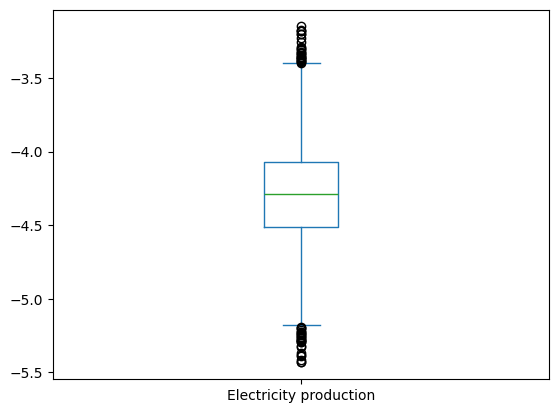

In [173]:
df_npv.plot(kind='box')